# Coarse Full Waveform Inversion

1. https://www.kaggle.com/competitions/waveform-inversion/code
2. https://www.kaggle.com/code/hanchenwang114/waveform-inversion-kaggle-competition-tutorial/notebook
3. https://arxiv.org/abs/2111.02926

## Imports

In [1]:
import os,sys; sys.path.append(os.getcwd().replace("fwi",""))
from util import get_torch_device_backend
from acoustic_forward_solver import acoustic_forward_solver, FWIPARAMETERS
from gauss_newton_solver import fwi_gn_solver
import chonknoris
import torch
import gpytorch
import lightning 
from matplotlib import pyplot,colors,cm
import os
import glob
import pandas as pd
import numpy as np
import timeit
import neuralop
import time 
import pyKoLesky.cholesky
import qmcpy as qp  # qmcpy==1.6.3rc0
import fastgps # fastgps==0.0.4.1b0
import warnings

## Torch Setup

In [2]:
torch.set_default_dtype(torch.float64)
torch.manual_seed(17)
DEVICE,TORCH_BACKEND = get_torch_device_backend(deviceidx=0)
print("DEVICE = %s"%str(DEVICE))
print("TORCH_BACKEND = %s"%str(TORCH_BACKEND.__name__))
EPS = torch.finfo(torch.get_default_dtype()).eps
EPS

DEVICE = cuda:0
TORCH_BACKEND = torch.cuda


2.220446049250313e-16

## Boilderplate

In [3]:
ROOT = "."
assert os.path.isfile(ROOT+"/fwi.ipynb")

In [4]:
pyplot.style.use('seaborn-v0_8-whitegrid')
COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv(ROOT+"/../xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
COLORS[:3] = COLORS[:3][::-1]
LWTHICK = 3
LWTHIN = .05
HIGHLIGHTS = 4

## Load Dataset

In [5]:
pname = "RES7"
vtype = "Style_B"
tag = "SAVE"
outdir = './data/%s.%s.%s'%(pname,vtype,tag)
assert os.path.isdir(outdir)
p = FWIPARAMETERS[pname]
data = torch.load(outdir+"/data_nk.pt",weights_only=True)
for _key,_val in data.items():
    print("data[%s].shape = %s"%(_key,str(tuple(_val.shape))))
data["l2rerrors"] = torch.linalg.norm(data["velocity"][:,None]-data["vs"],dim=(-2,-1))/torch.linalg.norm(data["velocity"][:,None],dim=(-2,-1)) # TODO: remove after patching in fwi_gn_solver
R,Ns,Nt,Nx = data["wavefield"].shape
p

data[vs].shape = (1000, 41, 7, 7)
data[rmses].shape = (1000, 41)
data[times].shape = (41,)
data[relaxations].shape = (1000, 41)
data[lrs].shape = (1000, 41)
data[updated].shape = (1000, 40)
data[Linvs].shape = (1000, 40, 49, 49)
data[l2rerrors].shape = (1000, 41)
data[v_true].shape = (1000, 7, 7)
data[w_true].shape = (1000, 5, 100, 7)
data[velocity].shape = (1000, 7, 7)
data[wavefield].shape = (1000, 5, 100, 7)
data[tidxs].shape = (750,)
data[vidxs].shape = (250,)


{'name': 'RES7',
 'nx': 7,
 'dx': 10,
 'nbc': 12,
 'nt': 101,
 'dt': 0.001,
 'freq': 35,
 'coord_sx': [1.0, 17.5, 35.0, 53.0, 70.0],
 'coord_sz': [1, 1, 1, 1, 1]}

## Explore Dataset

In [6]:
print("L2 relative errors")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["l2rerrors"]).describe().T.iloc[::5])

L2 relative errors


,count,mean,std,min,25%,50%,75%,max
0,1000.0,8.085168e-02,1.062751e-02,5.884689e-02,7.395257e-02,7.922804e-02,8.593752e-02,1.604743e-01
5,1000.0,2.232564e-02,7.595067e-03,5.178808e-03,1.771527e-02,2.188680e-02,2.584306e-02,7.766113e-02
10,1000.0,7.723026e-03,4.854020e-03,1.500691e-04,4.016224e-03,6.938815e-03,1.051257e-02,3.248156e-02
15,1000.0,1.049413e-03,1.839207e-03,1.734459e-07,4.498661e-05,3.019056e-04,1.205582e-03,1.743219e-02
20,1000.0,2.672817e-05,3.340649e-04,1.812898e-14,2.434204e-09,3.140117e-08,2.538875e-07,7.961543e-03
25,1000.0,2.317613e-07,5.265627e-06,9.799588e-15,5.953762e-14,2.817542e-13,2.144311e-11,1.440320e-04
30,1000.0,4.939515e-11,1.139824e-09,8.776707e-15,3.612922e-14,6.737475e-14,1.460192e-13,3.196415e-08
35,1000.0,1.197110e-13,4.293583e-13,8.776707e-15,3.464388e-14,6.271673e-14,1.242688e-13,1.130832e-11
40,1000.0,1.005559e-13,1.060052e-13,8.749674e-15,3.464388e-14,6.271673e-14,1.227266e-13,6.689144e-13


In [7]:
print("Relaxations")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["relaxations"]).describe().T.iloc[::5])

Relaxations


,count,mean,std,min,25%,50%,75%,max
0,1000.0,1.000000e-05,1.694914e-21,1.000000e-05,1.000000e-05,1.000000e-05,1.000000e-05,1.000000e-05
5,1000.0,1.986563e-06,1.908627e-06,3.125000e-07,1.250000e-06,1.250000e-06,2.500000e-06,4.000000e-05
10,1000.0,7.625977e-08,7.978179e-08,9.765625e-09,3.906250e-08,3.906250e-08,7.812500e-08,1.250000e-06
15,1000.0,5.070801e-09,5.164914e-09,6.103516e-10,2.441406e-09,4.882813e-09,4.882813e-09,7.812500e-08
20,1000.0,1.390190e-09,2.164378e-09,1.907349e-11,3.051758e-10,6.103516e-10,1.220703e-09,3.906250e-08
25,1000.0,6.646061e-10,1.185609e-09,4.768372e-12,7.629395e-11,1.525879e-10,6.103516e-10,9.765625e-09
30,1000.0,3.254064e-09,1.536873e-08,1.192093e-12,1.525879e-10,6.103516e-10,1.220703e-09,3.125000e-07
35,1000.0,8.749679e-08,4.891108e-07,9.536743e-12,1.220703e-09,4.882813e-09,3.906250e-08,1.000000e-05
40,1000.0,2.781936e-06,1.565411e-05,9.536743e-12,3.906250e-08,1.562500e-07,7.812500e-07,3.200000e-04


In [8]:
print("Learning rates")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["lrs"]).describe().T.iloc[::5])

Learning rates


,count,mean,std,min,25%,50%,75%,max
0,1000.0,1.000000,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.0
5,1000.0,1.451000,0.497842,1.000000e+00,1.000000e+00,1.000000e+00,2.000000,2.0
10,1000.0,1.814000,0.575965,1.000000e+00,2.000000e+00,2.000000e+00,2.000000,4.0
15,1000.0,1.768000,0.769915,1.000000e+00,1.000000e+00,2.000000e+00,2.000000,8.0
20,1000.0,1.335750,0.500835,2.500000e-01,1.000000e+00,1.000000e+00,2.000000,4.0
25,1000.0,0.846796,0.563389,9.765625e-04,2.500000e-01,1.000000e+00,1.000000,2.0
30,1000.0,0.178381,0.328018,9.536743e-07,3.906250e-03,3.125000e-02,0.125000,2.0
35,1000.0,0.013175,0.090762,9.313226e-10,7.629395e-06,2.441406e-04,0.001953,2.0
40,1000.0,0.001775,0.032865,9.094947e-13,7.450581e-09,2.384186e-07,0.000004,1.0


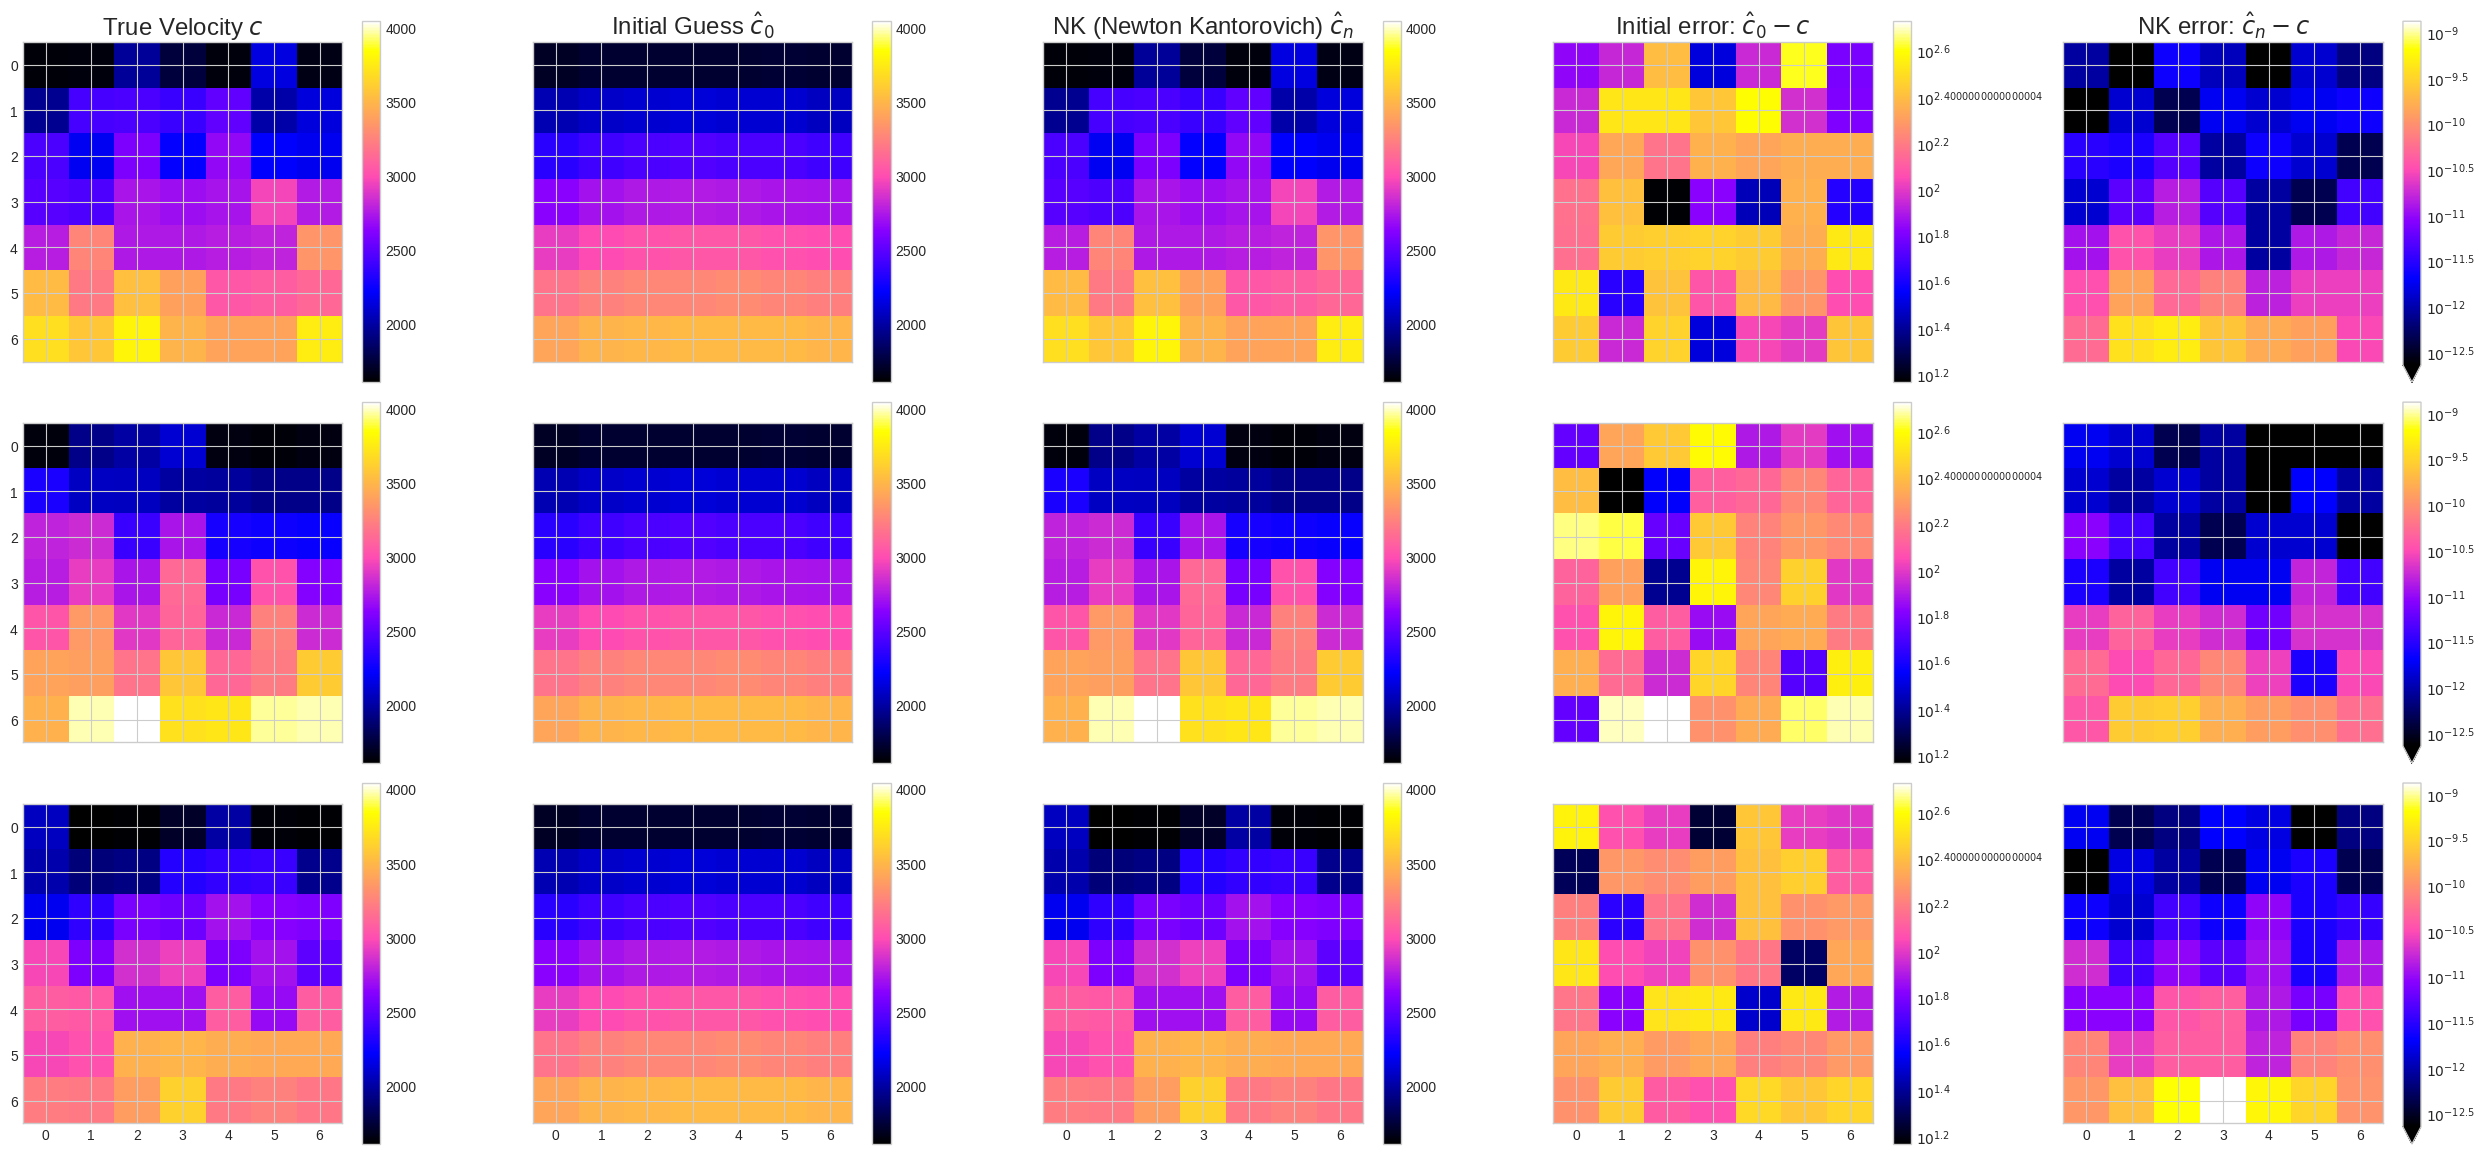

In [9]:
def plot_nk_velocities(v_true, v0, vfinal):
    initial_error_log10 = torch.log10(torch.abs(v_true-v0))
    final_error_log10 = torch.log10(torch.abs(v_true-vfinal))
    final_error_log10[final_error_log10==-torch.inf] = final_error_log10[final_error_log10.isfinite()].min()
    _initial_error_log10_amin = initial_error_log10.min()
    _initial_error_log10_amax = initial_error_log10.max()
    _final_error_log10_amin = final_error_log10.min()
    _final_error_log10_amax = final_error_log10.max()
    _cbmin = torch.min(v_true.min(),v0.min())
    _cbmax = torch.max(v_true.max(),v0.max())
    _plot_data = [
        (v_true,r"True Velocity $c$",_cbmin,_cbmax,False,None),
        (v0,r"Initial Guess $\hat{c}_0$",_cbmin,_cbmax,False,None),
        (vfinal,r"NK (Newton Kantorovich) $\hat{c}_n$",_cbmin,_cbmax,False,None),
        (initial_error_log10,r"Initial error: $\hat{c}_0-c$",_initial_error_log10_amin,_initial_error_log10_amax,True,None),
        (final_error_log10,r"NK error: $\hat{c}_n-c$",_final_error_log10_amin,_final_error_log10_amax,True,"min"),
        ]
    nrows = _plot_data[0][0].size(0)
    ncols = len(_plot_data)
    fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(5*ncols,4*nrows),sharex=True,sharey=True)
    ax = ax.reshape((nrows,ncols))
    for j,(_v,name,_vmin,_vmax,log10ed,extend) in enumerate(_plot_data):
        for i in range(nrows):
            cax = ax[i,j].imshow(_v[i].cpu(),cmap="gnuplot2",vmin=_vmin if _vmin is not None else None,vmax=_vmax if _vmax is not None else None)
            cbar = fig.colorbar(cax,extend=extend)
            if log10ed:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore",UserWarning)
                    cbar.ax.set_yticklabels([r"$10^{%s}$"%(int(_tick) if _tick%1==0 else _tick) for _tick in cbar.ax.get_yticks()]) 
        ax[0,j].set_title(name,fontsize="xx-large")
    fig.tight_layout()
    return fig,ax 
_R = 3
fig,ax = plot_nk_velocities(data["velocity"][:_R],data["vs"][:_R,0],data["vs"][:_R,-1])
fig.savefig(outdir+"/fwi_data.png",dpi=256)

/home/aleksei.sorokin/DeepNewtonOperator/chonknoris/plots.py:99: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i,j].legend(frameon=False,fontsize="xx-large")


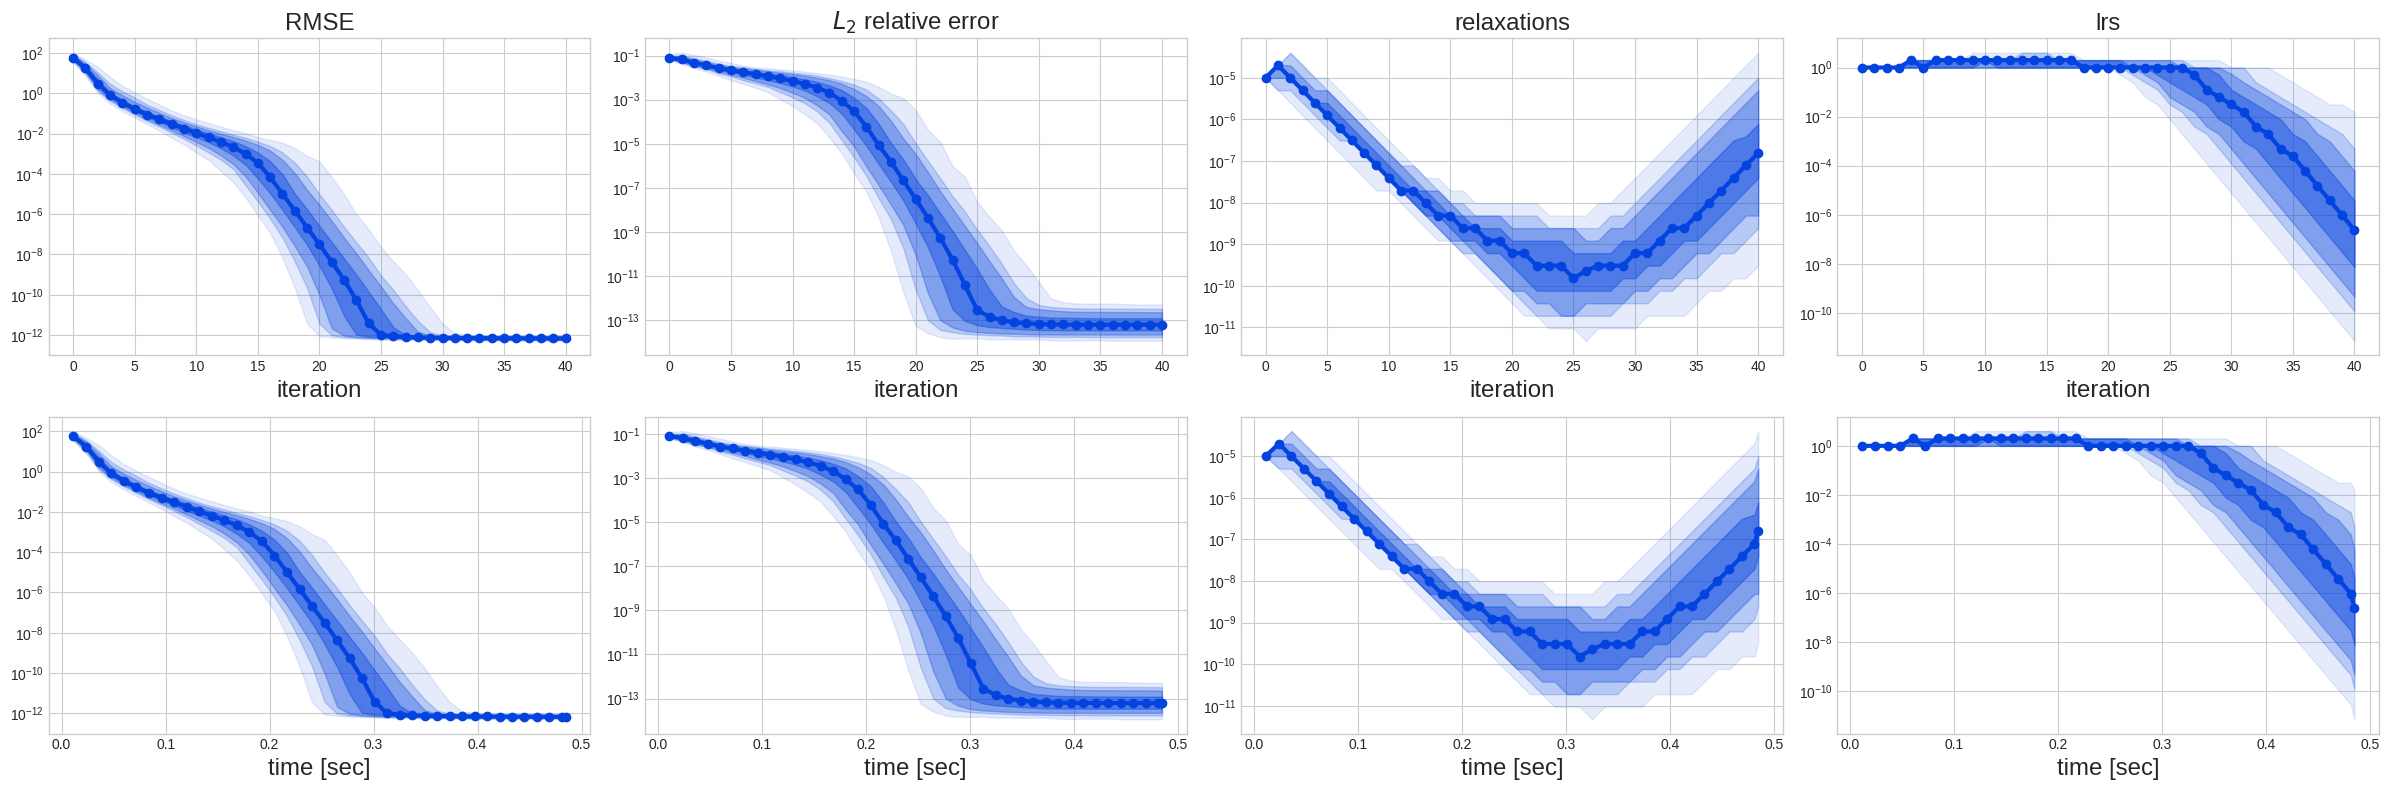

In [10]:
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [(None,data["rmses"],None)],
            [(None,data["l2rerrors"],None)],
            [(None,data["relaxations"],None)],
            [(None,data["lrs"],None)],

        ],
        [
            [(data["times"].cumsum(0),data["rmses"],None)],
            [(data["times"].cumsum(0),data["l2rerrors"],None)],
            [(data["times"].cumsum(0),data["relaxations"],None)],
            [(data["times"].cumsum(0),data["lrs"],None)],

        ],
    ],
    sharex = False,
    titles = [["RMSE",r"$L_2$ relative error","relaxations","lrs"],[None,None,None,None]],
    xlabels = [["iteration"],["time [sec]"]],
    xlogscale = False,
    colors = [COLORS[0]],
    ylogscale = True,
    fsx=4,fsy=6)
fig.tight_layout()
fig.savefig(outdir+"/fwi_coarse_nk_convergence.pdf",bbox_inches="tight")

## Gauss Newton Solves

In [ ]:
vref = data["velocity"][:10].to(DEVICE)
w = data["wavefield"][:10].to(DEVICE)
v0 = data["vs"][:10,0].to(DEVICE)

### Standard

In [12]:
_,_data_gn = fwi_gn_solver(p,w,v0,num_newton_iter=40,relaxation=1e-5,lr=1,vref=vref,use_pca=False,store_Linvs=True)

    iter of 40     | time      | RMSE                                                             | L2 relative error                                   | relaxations                                         | lrs                                                 |
                   |           | 5%           median       mean         95%          finite %     | 5%           median       mean         95%          | 5%           median       mean         95%          | 5%           median       mean         95%          |
    -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0              | 6.93e+00  | 2.62e+01     3.95e+01     3.91e+01     5.36e+01     100.0        | 6.93e-02     7.53e-02     7.69e-02     8.80e-02     | 1.00e-05     1.00e-05     1.00e-05     1.00e-05     | 1.00e+

KeyboardInterrupt: 

In [ ]:
_L = torch.linalg.solve_triangular(torch.eye(_data_gn["Linvs"].size(-1),device=DEVICE),_data_gn["Linvs"].to(DEVICE),upper=False)
_Theta = torch.einsum("rikl,rijl->rikj",_L,_L)
_cond_nums = torch.linalg.cond(_Theta)

### PCA

velocity_train_mean.shape = (7, 7)
velocity_train_std.shape = (7, 7)
u_svd.shape = (750, 49)
s_svd.shape = (49,)
vh_svd.shape = (49, 49)
mat_svd_scaled.shape = (49, 49)
    iter of 40     | time      | RMSE                                                             | L2 relative error                                   | relaxations                                         | lrs                                                 |
                   |           | 5%           median       mean         95%          finite %     | 5%           median       mean         95%          | 5%           median       mean         95%          | 5%           median       mean         95%          |
    -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0              | 6.28e+00  | 4.30e+01    

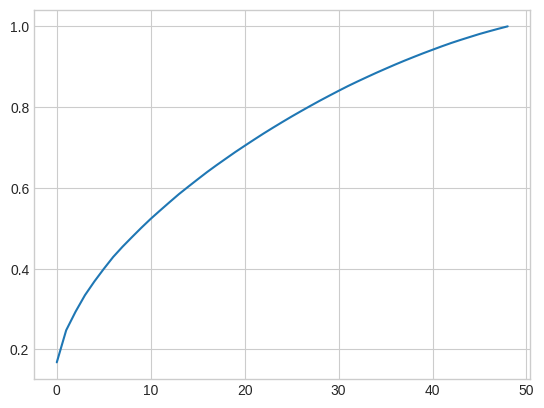

In [ ]:
velocity_train_mean = data["velocity"][data["tidxs"]].mean(0)
print("velocity_train_mean.shape = %s"%str(tuple(velocity_train_mean.shape)))
velocity_train_std = data["velocity"][data["tidxs"]].std(0)
print("velocity_train_std.shape = %s"%str(tuple(velocity_train_std.shape)))
velocity_train_centered = (data["velocity"][data["tidxs"]]-velocity_train_mean)/velocity_train_std
velocity_train_centered_flat = velocity_train_centered.flatten(start_dim=1)
u_svd,s_svd,vh_svd = torch.linalg.svd(velocity_train_centered_flat,full_matrices=False)
print("u_svd.shape = %s"%str(tuple(u_svd.shape)))
print("s_svd.shape = %s"%str(tuple(s_svd.shape)))
print("vh_svd.shape = %s"%str(tuple(vh_svd.shape)))
assert torch.allclose((u_svd*s_svd)@vh_svd,velocity_train_centered_flat)
_mat_svd = (s_svd[:,None]*vh_svd).to(DEVICE)
mat_svd_scaled = _mat_svd*velocity_train_std.flatten(start_dim=-2).to(DEVICE)
print("mat_svd_scaled.shape = %s"%str(tuple(mat_svd_scaled.shape)))
explained_var_ratio = s_svd**2/(s_svd**2).sum()
explained_var_ratio_cumsum = explained_var_ratio.cumsum(dim=0)
pyplot.plot(explained_var_ratio_cumsum);
pca_data={
    "mat_svd_scaled": mat_svd_scaled.to(DEVICE),
    "velocity_train_mean": velocity_train_mean.to(DEVICE),
    "velocity_train_std": velocity_train_std.to(DEVICE),
    "vh_svd": vh_svd.to(DEVICE),
    "s_svd": s_svd.to(DEVICE)}
_,_data_gn_pca = fwi_gn_solver(p,w,v0,num_newton_iter=40,relaxation=1e2,lr=1,vref=vref,use_pca=True,pca_data=pca_data,store_Linvs=True)

In [ ]:
_L = torch.linalg.solve_triangular(torch.eye(_data_gn_pca["Linvs"].size(-1),device=DEVICE),_data_gn_pca["Linvs"].to(DEVICE),upper=False)
_Theta = torch.einsum("rikl,rijl->rikj",_L,_L)
_cond_nums_pca = torch.linalg.cond(_Theta)

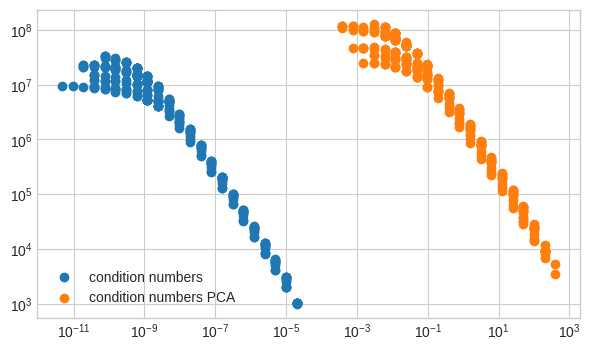

In [ ]:
fig,ax = pyplot.subplots(figsize=(7,4))
ax.scatter(_data_gn["relaxations"][:,1:].flatten().cpu(),_cond_nums.flatten().cpu(),label="condition numbers")
ax.scatter(_data_gn_pca["relaxations"][:,1:].flatten().cpu(),_cond_nums_pca.flatten().cpu(),label="condition numbers PCA")
ax.set_xscale("log",base=10)
ax.set_yscale("log",base=10)
ax.legend(frameon=False);

## Initial Guess Model

### Load Data

In [11]:
outdir_igmodels = outdir+"/MODELS_IG"
if not os.path.isdir(outdir_igmodels): os.mkdir(outdir_igmodels)

In [12]:
inputs_raw_ig_t = data["wavefield"][data["tidxs"]].flatten(start_dim=1)
inputs_raw_ig_v = data["wavefield"][data["vidxs"]].flatten(start_dim=1)
outputs_raw_ig_t = data["velocity"][data["tidxs"]].flatten(start_dim=1)
outputs_raw_ig_v = data["velocity"][data["vidxs"]].flatten(start_dim=1)
inputs_raw_ig_t_mean = inputs_raw_ig_t.mean(0) 
inputs_raw_ig_t_std = inputs_raw_ig_t.std(0) 
inputs_raw_ig_t_std[inputs_raw_ig_t_std==0] = 1
outputs_raw_ig_t_mean = outputs_raw_ig_t.mean(0) 
outputs_raw_ig_t_std = outputs_raw_ig_t.std(0) 
#outputs_raw_ig_t_std[outputs_raw_ig_t_std==0] = 1
#outputs_raw_ig_t_mean[:] = 0
outputs_raw_ig_t_std[:] = 1
inputs_ig_t = (inputs_raw_ig_t-inputs_raw_ig_t_mean)/inputs_raw_ig_t_std
inputs_ig_v = (inputs_raw_ig_v-inputs_raw_ig_t_mean)/inputs_raw_ig_t_std
outputs_ig_t = (outputs_raw_ig_t-outputs_raw_ig_t_mean)/outputs_raw_ig_t_std
outputs_ig_v = (outputs_raw_ig_v-outputs_raw_ig_t_mean)/outputs_raw_ig_t_std
print("inputs_raw_ig_t.shape = %s"%str(tuple(inputs_raw_ig_t.shape)))
print("inputs_raw_ig_v.shape = %s"%str(tuple(inputs_raw_ig_v.shape)))
print("inputs_raw_ig_t_mean.shape = %s"%str(tuple(inputs_raw_ig_t_mean.shape)))
print("inputs_raw_ig_t_std.shape = %s"%str(tuple(inputs_raw_ig_t_std.shape)))
print("outputs_raw_ig_t.shape = %s"%str(tuple(outputs_raw_ig_t.shape)))
print("outputs_raw_ig_v.shape = %s"%str(tuple(outputs_raw_ig_v.shape)))
print("outputs_raw_ig_t_mean.shape = %s"%str(tuple(outputs_raw_ig_t_mean.shape)))
print("outputs_raw_ig_t_std.shape = %s"%str(tuple(outputs_raw_ig_t_std.shape)))
print("inputs_ig_t.shape = %s"%str(tuple(inputs_ig_t.shape)))
print("inputs_ig_v.shape = %s"%str(tuple(inputs_ig_v.shape)))
print("outputs_ig_t.shape = %s"%str(tuple(outputs_ig_t.shape)))
print("outputs_ig_v.shape = %s"%str(tuple(outputs_ig_v.shape)))

inputs_raw_ig_t.shape = (750, 3500)
inputs_raw_ig_v.shape = (250, 3500)
inputs_raw_ig_t_mean.shape = (3500,)
inputs_raw_ig_t_std.shape = (3500,)
outputs_raw_ig_t.shape = (750, 49)
outputs_raw_ig_v.shape = (250, 49)
outputs_raw_ig_t_mean.shape = (49,)
outputs_raw_ig_t_std.shape = (49,)
inputs_ig_t.shape = (750, 3500)
inputs_ig_v.shape = (250, 3500)
outputs_ig_t.shape = (750, 49)
outputs_ig_v.shape = (250, 49)


### MLP

In [17]:
import gc
gc.collect()
torch.cuda.empty_cache()

save_dir = outdir_igmodels
name = "MLP"
resume = True

ds_ig_t = chonknoris.DatasetClassic(inputs_ig_t,outputs_ig_t)
ds_ig_v = chonknoris.DatasetClassic(inputs_ig_v,outputs_ig_v)
print("len(ds_ig_t) = %d"%len(ds_ig_t))
print("len(ds_ig_v) = %d"%len(ds_ig_v))

dl_mlp_ig_t = torch.utils.data.DataLoader(ds_ig_t,batch_size=2**8,collate_fn=tuple,shuffle=True)
dl_mlp_ig_v = torch.utils.data.DataLoader(ds_ig_v,batch_size=len(ds_ig_v),collate_fn=tuple,shuffle=False)
print("len(dl_mlp_t) = %d"%len(dl_mlp_ig_t))
print("len(dl_mlp_v) = %d"%len(dl_mlp_ig_v))
print()

nn_ig = chonknoris.MLP(mlp_layer_nodes=[Ns*Nt*Nx]+5*[Nx*Nx],activation_function=torch.nn.Tanh())
#nn = chonknoris.MLP(mlp_layer_nodes=[1+Nx**2+Ns*Nt*Nx]+5*[1000]+[Nx**2*(1+Nx**2)//2],activation_function=torch.nn.Tanh())
lnn_ig = chonknoris.LightningNN(nn_ig,lr=1e-2,use_l2rerror_loss=True).to(DEVICE)
print(lnn_ig)

csv_logger = lightning.pytorch.loggers.CSVLogger(save_dir=save_dir,name=name,version='csv')
trainer = lightning.Trainer(
    max_epochs = 100,
    logger = [csv_logger],
    #accelerator = "cpu",
    #limit_train_batches=2**10,
    #log_every_n_steps = 1e10,
    enable_progress_bar = True,
    #num_sanity_val_steps = 0,
    #gradient_clip_val = 1.0,
    #gradient_clip_algorithm = "norm",
  )
trainer.fit(
    model = lnn_ig, 
    train_dataloaders = dl_mlp_ig_t,
    val_dataloaders = dl_mlp_ig_v,
    ckpt_path = sorted(glob.glob("./%s/%s/csv/checkpoints/*.ckpt"%(save_dir,name)),key=os.path.getmtime)[-1] if resume else None,
)


Trainer will use only 1 of 7 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=7)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


len(ds_ig_t) = 750
len(ds_ig_v) = 250
len(dl_mlp_t) = 3
len(dl_mlp_v) = 1

LightningNN(
  (nn): MLP(
    (nn_sequential): Sequential(
      (0): Linear(in_features=3500, out_features=49, bias=True)
      (1): Tanh()
      (2): Linear(in_features=49, out_features=49, bias=True)
      (3): Tanh()
      (4): Linear(in_features=49, out_features=49, bias=True)
      (5): Tanh()
      (6): Linear(in_features=49, out_features=49, bias=True)
      (7): Tanh()
      (8): Linear(in_features=49, out_features=49, bias=True)
    )
  )
)


IndexError: list index out of range

,train_avg_l2error,val_avg_l2error,train_avg_l2rerror,val_avg_l2rerror,train_loss,val_loss,train_rmse,val_rmse
0,2275.245613,2275.727848,0.999758,0.998867,52537.537016,52380.901685,229.205278,228.868743
12,2218.631986,2236.430520,0.975845,0.982340,50000.318240,50674.275620,223.605907,225.109475
24,2187.785764,2219.658236,0.962507,0.975319,48645.714099,49919.464984,220.553598,223.426643
36,2155.742608,2218.800287,0.949600,0.975082,47264.200067,49969.603641,217.401125,223.538819
48,2130.536267,2207.711733,0.938945,0.970985,46076.566196,49531.143841,214.650299,222.555934
60,2079.975036,2215.530427,0.918707,0.973633,43880.133607,49964.812181,209.475751,223.528102
72,2048.930005,2230.115489,0.906236,0.981451,42579.737866,50781.753299,206.343354,225.348071
84,2024.495152,2246.399988,0.895287,0.988931,41559.213572,51647.026662,203.859370,227.259822
96,1995.216701,2238.791228,0.883752,0.985112,40424.866658,51360.201265,201.059224,226.627892


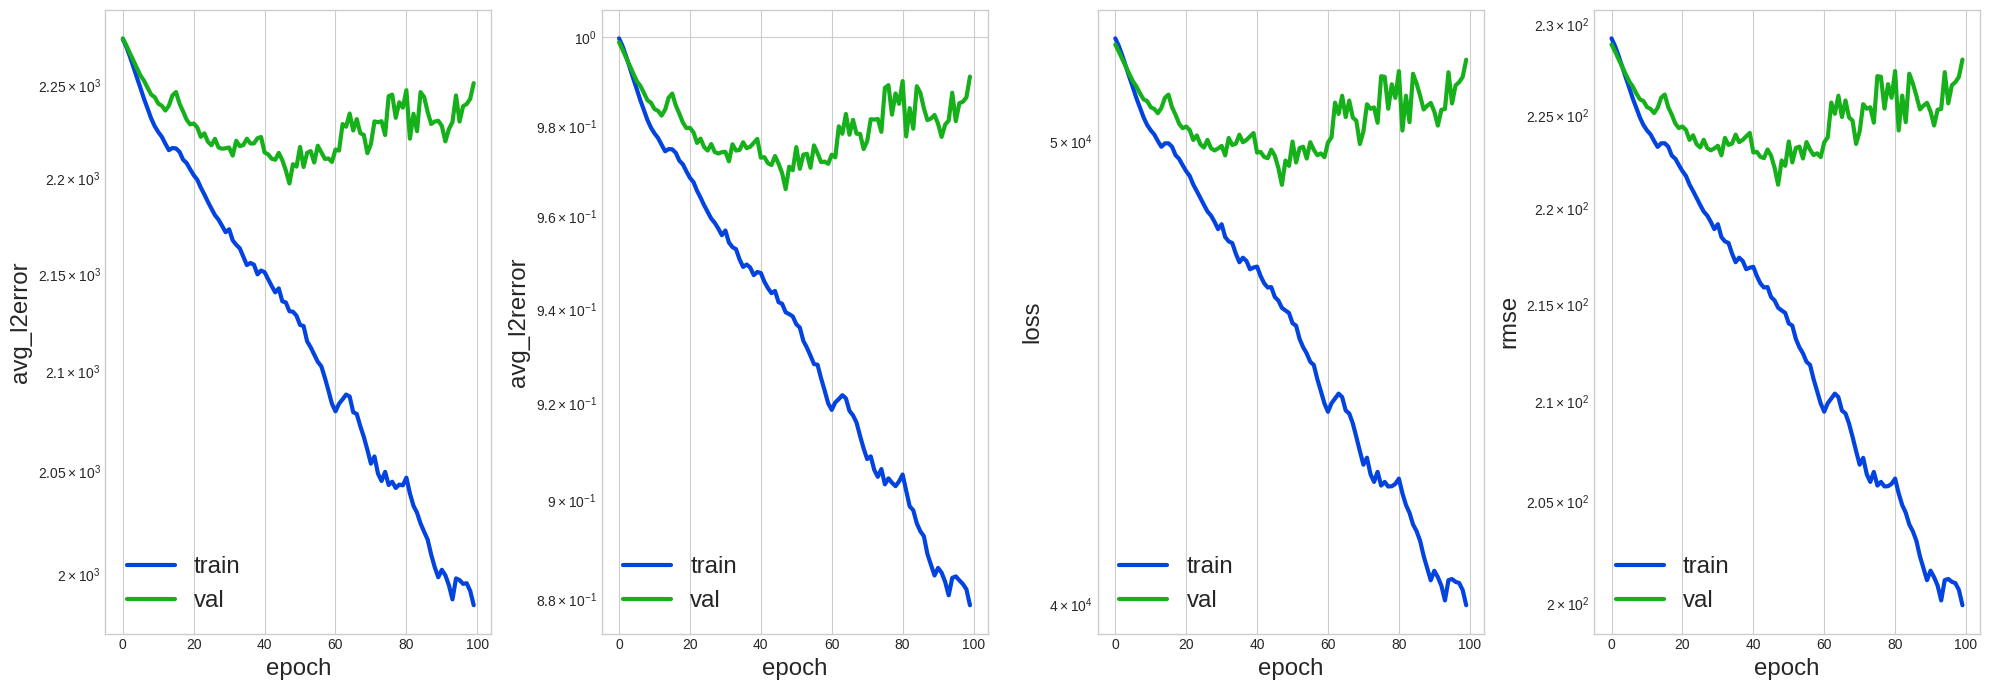

In [ ]:
metrics = chonknoris.parse_metrics("%s/%s/csv/metrics.csv"%(save_dir,name))
fig,ax = chonknoris.plot_metrics(metrics,linewidth=LWTHICK,color_train=COLORS[0],color_val=COLORS[1],s0=0)
fig.tight_layout()
metrics.iloc[::max(1,len(metrics)//8)]

In [ ]:
lnn_ig = lnn_ig.to(DEVICE) 
with torch.no_grad(), torch.inference_mode():
    outputs_v_hat_sgp_ig_raw_mlp = lnn_ig(inputs_ig_v.to(DEVICE))
outputs_v_hat_sgp_ig_mlp = outputs_v_hat_sgp_ig_raw_mlp*outputs_raw_ig_t_std.to(DEVICE)+outputs_raw_ig_t_mean.to(DEVICE)
print("l2 relative error: %.2e"%(torch.linalg.norm(outputs_v_hat_sgp_ig_mlp-outputs_raw_ig_v.to(DEVICE),dim=-1)/torch.linalg.norm(outputs_raw_ig_v.to(DEVICE),dim=-1)).mean())

l2 relative error: 8.04e-02


### GP

In [16]:
import gc
gc.collect()
torch.cuda.empty_cache()

EPS64 = fastgps.util.EPS64

sgp_ig = fastgps.StandardGP(
    Ns*Nt*Nx,
    data={
        "x": inputs_ig_t.to(DEVICE),
        "y": outputs_ig_t.to(DEVICE).T},
    shape_batch=[Nx*Nx],
    device=DEVICE,
    compile_dist_func=True,
    #scale = 1, 
    shape_scale = [Nx*Nx,1],
    # shape_scale = [1],
    lengthscales=Ns*Nt*Nx,
    # shape_lengthscales=[1],
    shape_lengthscales=[Ns*Nt*Nx],
    noise=1e-8,
    shape_noise=[Nx*Nx,1],
    # tfs_scale = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_lengthscales = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_noise = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_scale = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_lengthscales = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_noise = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_scale = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
    # tfs_lengthscales = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
    # tfs_noise = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
    # shape_noise=[1],
    requires_grad_noise=True,
    kernel_class="gaussian",
)
for pname,pval in sgp_ig.named_parameters():
    print("%s.shape = %s"%(pname,str(tuple(pval.shape))))
print()
fit_data_sgp_ig = sgp_ig.fit(
    loss_metric = "CV",
    #cv_weights = 1/torch.linalg.norm(outputs_ig_t.to(DEVICE),dim=1),
    iterations=100,
    verbose=10,
    store_hists=True,
    stop_crit_wait_iterations=np.inf,
    stop_crit_improvement_threshold=1e-1,
    lr = 1e-3
    #optimizer = torch.optim.Rprop(sgp_ig.parameters(),lr=1e-1,etas=(1/1000,1001/1000),step_sizes=(0,5))
    )

raw_scale.shape = (49, 1)
raw_lengthscales.shape = (3500,)
raw_noise.shape = (49, 1)
raw_factor_task_kernel.shape = (1, 0)
raw_noise_task_kernel.shape = (1,)

     iter of 1.0e+02 | loss       | term1      | term2     
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 7.22e+08   | nan        | nan       
            1.00e+01 | 7.22e+08   | nan        | nan       
            2.00e+01 | 7.22e+08   | nan        | nan       
            3.00e+01 | 7.22e+08   | nan        | nan       
            4.00e+01 | 7.21e+08   | nan        | nan       
            5.00e+01 | 7.15e+08   | nan        | nan       
            6.00e+01 | 6.86e+08   | nan        | nan       
            7.00e+01 | 6.63e+08   | nan        | nan       
            8.00e+01 | 9.29e+08   | nan        | nan       
            9.00e+01 | 1.18e+09   | nan        | nan       
            1.00e+02 | 1.23e+09   | nan        | nan       


In [17]:
outputs_v_hat_sgp_ig_raw = sgp_ig.post_mean(inputs_ig_v.to(DEVICE)).T
outputs_v_hat_sgp_ig = outputs_v_hat_sgp_ig_raw*outputs_raw_ig_t_std.to(DEVICE)+outputs_raw_ig_t_mean.to(DEVICE)
print("l2 relative error: %.2e"%(torch.linalg.norm(outputs_v_hat_sgp_ig-outputs_raw_ig_v.to(DEVICE),dim=-1)/torch.linalg.norm(outputs_raw_ig_v.to(DEVICE),dim=-1)).mean())

l2 relative error: 4.82e-02


dict_keys(['iterations', 'loss_hist', 'scale_hist', 'lengthscales_hist', 'noise_hist', 'task_kernel_hist'])
fit_data_sgp_ig[loss_hist].shape = (101,)
fit_data_sgp_ig[scale_hist].shape = (101, 49, 1)
fit_data_sgp_ig[lengthscales_hist].shape = (101, 3500)
fit_data_sgp_ig[noise_hist].shape = (101, 49, 1)


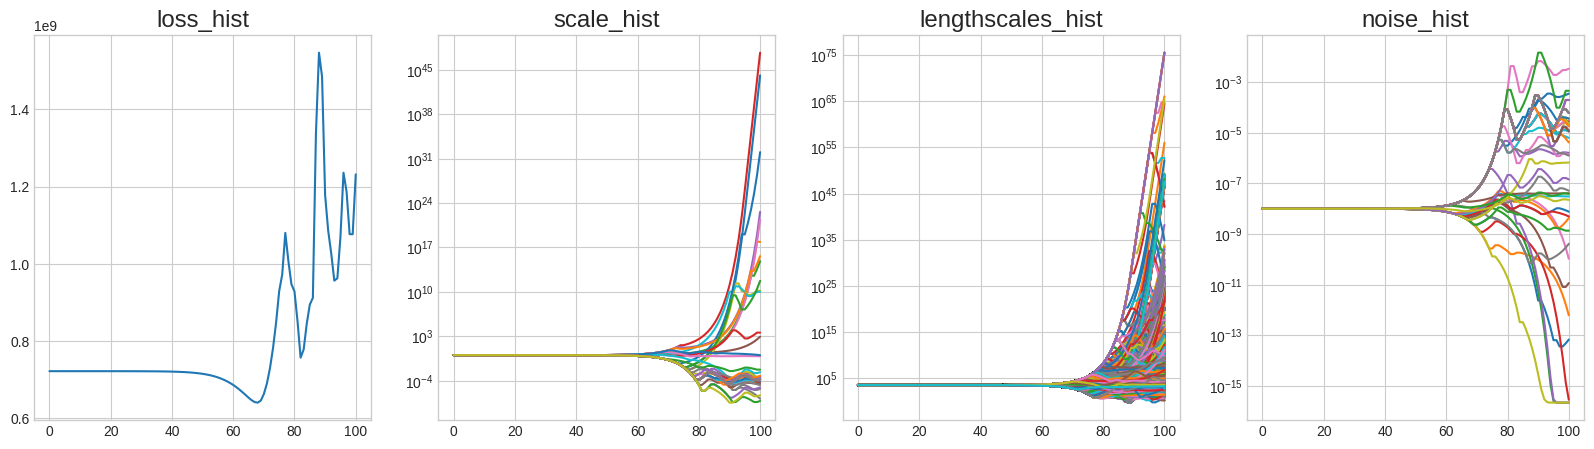

In [18]:
print(fit_data_sgp_ig.keys())
keys_to_plot_log10ed = [
    ('loss_hist',False),
    ('scale_hist',True),
    ('lengthscales_hist',True),
    ('noise_hist',True)]
ncols = len(keys_to_plot_log10ed)
fig,ax = pyplot.subplots(nrows=1,ncols=ncols,figsize=(5*ncols,5))
for i,(key,log10ed) in enumerate(keys_to_plot_log10ed):
    print("fit_data_sgp_ig[%s].shape = %s"%(key,str(tuple(fit_data_sgp_ig[key].shape))))
    if key in ["noise_hist","scale_hist"] and fit_data_sgp_ig[key].ndim==3:
        ax[i].plot(torch.arange(fit_data_sgp_ig[key].size(0)),fit_data_sgp_ig[key][:,:,0])
    else:
        ax[i].plot(torch.arange(fit_data_sgp_ig[key].size(0)),fit_data_sgp_ig[key])
    ax[i].set_title(key,fontsize="xx-large")
    if log10ed: ax[i].set_yscale('log',base=10)

## Dataloader

In [19]:
M = data["vs"].size(1) # total number of iterations
print("M = %d"%M)
#Midxs = torch.arange(10)
#Midxs = torch.arange(10,15)
# Midxs = torch.tensor([1,2,4,7,11,16,22,29,37])
Midxs = torch.arange(0,M-1)
# Midxs = torch.linspace(1,39,steps=10,dtype=int)
# Midxs = torch.linspace(1,39,steps=20,dtype=int)
#Midxs = torch.linspace(1,74,steps=25,dtype=int)
#Midxs = torch.linspace(1,29,steps=10,dtype=int)
#Midxs = torch.linspace(1,29,steps=5,dtype=int)
#Midxs = torch.linspace(1,9,steps=5,dtype=int)
print("Midxs = %s"%str(Midxs.numpy()))
print("len(Midxs) = %d"%len(Midxs))
assert (Midxs<(M-1)).all(), "Midxs must be less than M-1=%d"%(M-1)
outdir_chonknoris = outdir+"/MODELS_L"
if not os.path.isdir(outdir_chonknoris): os.mkdir(outdir_chonknoris)

M = 41
Midxs = [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
len(Midxs) = 40


In [20]:
import gc
gc.collect()
torch.cuda.empty_cache()
_vs = data["vs"][:,Midxs]
vs_t = _vs[data["tidxs"]]
vs_v = _vs[data["vidxs"]]
_relaxations = data["relaxations"][:,Midxs+1]
relaxations_t = _relaxations[data["tidxs"]]
relaxations_v = _relaxations[data["vidxs"]]
_wavefield_full = torch.tile(data["wavefield"][:,None,:,:,:],(1,len(Midxs),1,1,1))
wavefield_full_t = _wavefield_full[data["tidxs"]]
wavefield_full_v = _wavefield_full[data["vidxs"]]
_eyeNx2 = torch.eye(Nx**2,device=DEVICE)
_Linvs = data["Linvs"][:,Midxs]
_L = torch.linalg.solve_triangular(_Linvs.to(DEVICE),_eyeNx2,upper=False).cpu()
# common_relaxation = 1e-5
# Theta = (torch.einsum("rijk,rilk->rijl",_L,_L)-_relaxations[:,:,None,None].to(DEVICE))*_eyeNx2+common_relaxation*_eyeNx2
# _L = torch.linalg.cholesky(Theta).cpu()
# _Linvs = data["Linvs"][:,Midxs]
# Linvs_t = _Linvs[data["tidxs"]]
# Linvs_v = _Linvs[data["vidxs"]]
# L_t = torch.linalg.solve_triangular(Linvs_t.to(DEVICE),_eyeNx2,upper=False).to("cpu")-relaxations_t[...,None,None]
# L_v = torch.linalg.solve_triangular(Linvs_v.to(DEVICE),_eyeNx2,upper=False).to("cpu")-relaxations_v[...,None,None]
# Theta_t = Theta[data["tidxs"]]
# Theta_v = Theta[data["vidxs"]]
#_L = data["Linvs"][:,Midxs]
L_t = _L[data["tidxs"]]
L_v = _L[data["vidxs"]]
#JtF_t = torch.einsum("rijk,rik->rij",L_t,torch.einsum("rikj,rik->rij",L_t,(vs_t[:,1:]-vs_t[:,:-1]).flatten(start_dim=-2)))
#JtF_v = torch.einsum("rijk,rik->rij",L_v,torch.einsum("rikj,rik->rij",L_v,(vs_v[:,1:]-vs_v[:,:-1]).flatten(start_dim=-2)))
_updated = data["updated"][:,Midxs]
updated_t = _updated[data["tidxs"]]
updated_v = _updated[data["vidxs"]]

In [21]:
print("vs_t.shape = %s"%str(tuple(vs_t.shape)))
print("vs_v.shape = %s"%str(tuple(vs_v.shape)))
print("relaxations_t.shape = %s"%str(tuple(relaxations_t.shape)))
print("relaxations_v.shape = %s"%str(tuple(relaxations_v.shape)))
print("wavefield_full_t.shape = %s"%str(tuple(wavefield_full_t.shape)))
print("wavefield_full_v.shape = %s"%str(tuple(wavefield_full_v.shape)))
# print("Linvs_t.shape = %s"%str(tuple(Linvs_t.shape)))
# print("Linvs_v.shape = %s"%str(tuple(Linvs_v.shape)))
# print("Theta_t.shape = %s"%str(tuple(Theta_t.shape)))
# print("Theta_v.shape = %s"%str(tuple(Theta_v.shape)))
print("L_t.shape = %s"%str(tuple(L_t.shape)))
print("L_v.shape = %s"%str(tuple(L_v.shape)))
# print("JtF_t.shape = %s"%str(tuple(JtF_t.shape)))
# print("JtF_v.shape = %s"%str(tuple(JtF_v.shape)))
print("updated_t.shape = %s"%str(tuple(updated_t.shape)))
print("updated_v.shape = %s"%str(tuple(updated_v.shape)))

vs_t.shape = (750, 40, 7, 7)
vs_v.shape = (250, 40, 7, 7)
relaxations_t.shape = (750, 40)
relaxations_v.shape = (250, 40)
wavefield_full_t.shape = (750, 40, 5, 100, 7)
wavefield_full_v.shape = (250, 40, 5, 100, 7)
L_t.shape = (750, 40, 49, 49)
L_v.shape = (250, 40, 49, 49)
updated_t.shape = (750, 40)
updated_v.shape = (250, 40)


In [22]:
lti0,lti1 = torch.tril_indices(Nx**2,Nx**2)
inputs_raw_t = torch.cat([torch.log(relaxations_t[updated_t][:,None]),vs_t[updated_t].flatten(start_dim=1),wavefield_full_t[updated_t].flatten(start_dim=1)],dim=-1)
inputs_raw_v = torch.cat([torch.log(relaxations_v[updated_v][:,None]),vs_v[updated_v].flatten(start_dim=1),wavefield_full_v[updated_v].flatten(start_dim=1)],dim=-1)
# inputs_raw_t = torch.cat([vs_t[:,:-1][updated_t].flatten(start_dim=1),wavefield_full_t[updated_t].flatten(start_dim=1)],dim=-1)
# inputs_raw_v = torch.cat([vs_v[:,:-1][updated_v].flatten(start_dim=1),wavefield_full_v[updated_v].flatten(start_dim=1)],dim=-1)
print("inputs_raw_t.shape = %s"%str(tuple(inputs_raw_t.shape)))
print("inputs_raw_v.shape = %s"%str(tuple(inputs_raw_v.shape)))
inputs_raw_t_mean = inputs_raw_t.mean(0).to(DEVICE)
inputs_raw_t_std = inputs_raw_t.std(0).to(DEVICE)
inputs_raw_t_std[inputs_raw_t_std==0] = 1
inputs_t = (inputs_raw_t-inputs_raw_t_mean.to("cpu"))/inputs_raw_t_std.to("cpu")
inputs_v = (inputs_raw_v-inputs_raw_t_mean.to("cpu"))/inputs_raw_t_std.to("cpu")
print("inputs_t.shape = %s"%str(tuple(inputs_raw_t.shape)))
print("inputs_v.shape = %s"%str(tuple(inputs_raw_v.shape)))
# outputs_t = (vs_t[:,1:]-vs_t[:,:-1])[updated_t].flatten(start_dim=1)
# outputs_v = (vs_v[:,1:]-vs_v[:,:-1])[updated_v].flatten(start_dim=1)
# outputs_t = Linvs_t[updated_t][:,lti0,lti1]
# outputs_v = Linvs_v[updated_v][:,lti0,lti1]
outputs_raw_t = L_t[updated_t]
outputs_raw_v = L_v[updated_v]
_Nxr2 = torch.arange(Nx*Nx)
outputs_raw_t[:,_Nxr2,_Nxr2] = outputs_raw_t[:,_Nxr2,_Nxr2]
outputs_raw_v[:,_Nxr2,_Nxr2] = outputs_raw_v[:,_Nxr2,_Nxr2]
outputs_raw_t = outputs_raw_t[:,lti0,lti1]
outputs_raw_v = outputs_raw_v[:,lti0,lti1]
outputs_raw_t_mean = outputs_raw_t.mean(0).to(DEVICE)
outputs_raw_t_std = outputs_raw_t.std(0).to(DEVICE)
# outputs_raw_t_mean[:] = 0
# outputs_raw_t_std[:] = 1
outputs_raw_t_std[outputs_raw_t_std==0] = 1
outputs_t = (outputs_raw_t-outputs_raw_t_mean.to("cpu"))/outputs_raw_t_std.to("cpu")
outputs_v = (outputs_raw_v-outputs_raw_t_mean.to("cpu"))/outputs_raw_t_std.to("cpu")
# outputs_t[:,_Nxr2,_Nxr2] = torch.log(outputs_t[:,_Nxr2,_Nxr2])
# outputs_v[:,_Nxr2,_Nxr2] = torch.log(outputs_v[:,_Nxr2,_Nxr2])
# outputs_t = outputs_t[:,lti0,lti1]
# outputs_v = outputs_v[:,lti0,lti1]
ds_t = chonknoris.DatasetClassic(inputs_t,outputs_t)
ds_v = chonknoris.DatasetClassic(inputs_v,outputs_v)
print("outputs_t.shape = %s"%str(tuple(outputs_t.shape)))
print("outputs_v.shape = %s"%str(tuple(outputs_v.shape)))
print("len(ds_t) = %d"%len(ds_t))
print("len(ds_v) = %d"%len(ds_v))

inputs_raw_t.shape = (22224, 3550)
inputs_raw_v.shape = (7437, 3550)
inputs_t.shape = (22224, 3550)
inputs_v.shape = (7437, 3550)
outputs_t.shape = (22224, 1225)
outputs_v.shape = (7437, 1225)
len(ds_t) = 22224
len(ds_v) = 7437


### Whitening + FastGP

In [23]:
_C = (inputs_t.T@inputs_t).to(DEVICE)
print("_C.shape = %s"%str(tuple(_C.shape)))
if True:
    print("Eigen-Whitening")
    _C_evals,_C_evecs = torch.linalg.eigh(_C)
    print("_C_evals.min() = %.2e"%_C_evals.min())
    if _C_evals.min()<=0: _C_evals = _C_evals-_C_evals.min()+1e-8
    assert torch.allclose((_C_evecs*_C_evals)@_C_evecs.T,_C,atol=1e-5)
    W_white = (_C_evecs/torch.sqrt(_C_evals))@_C_evecs.T
    Winv_white = (_C_evecs*torch.sqrt(_C_evals))@_C_evecs.T
else:
    print("Chol-Whitening")
    Winv_white = torch.linalg.cholesky(_C+1e-3*torch.eye(_C.size(0),device=DEVICE),upper=True)
    W_white = torch.linalg.solve_triangular(Winv_white,torch.eye(_C.size(0),device=DEVICE),upper=True)
print("W_white.shape = %s"%str(tuple(W_white.shape)))
print("Winv_white.shape = %s"%str(tuple(Winv_white.shape)))
assert torch.allclose(W_white@Winv_white,torch.eye(Winv_white.size(-1),device=DEVICE),atol=1e-8)

_C.shape = (3550, 3550)
Eigen-Whitening
_C_evals.min() = -3.16e-08
W_white.shape = (3550, 3550)
Winv_white.shape = (3550, 3550)


In [24]:
inputs_zca_t = torch.einsum("ij,...j->...i",W_white,inputs_t.to(DEVICE)).to("cpu")
inputs_zca_mean = inputs_zca_t.mean(0).to(DEVICE)
inputs_zca_std = inputs_zca_t.std(0).to(DEVICE)
inputs_zca_std[inputs_zca_std==0] = 1
print("inputs_zca.shape = %s"%str(tuple(inputs_zca_t.shape)))
print("inputs_zca_mean.shape = %s"%str(tuple(inputs_zca_mean.shape)))
print("inputs_zca_std.shape = %s"%str(tuple(inputs_zca_std.shape)))

inputs_zca.shape = (22224, 3550)
inputs_zca_mean.shape = (3550,)
inputs_zca_std.shape = (3550,)


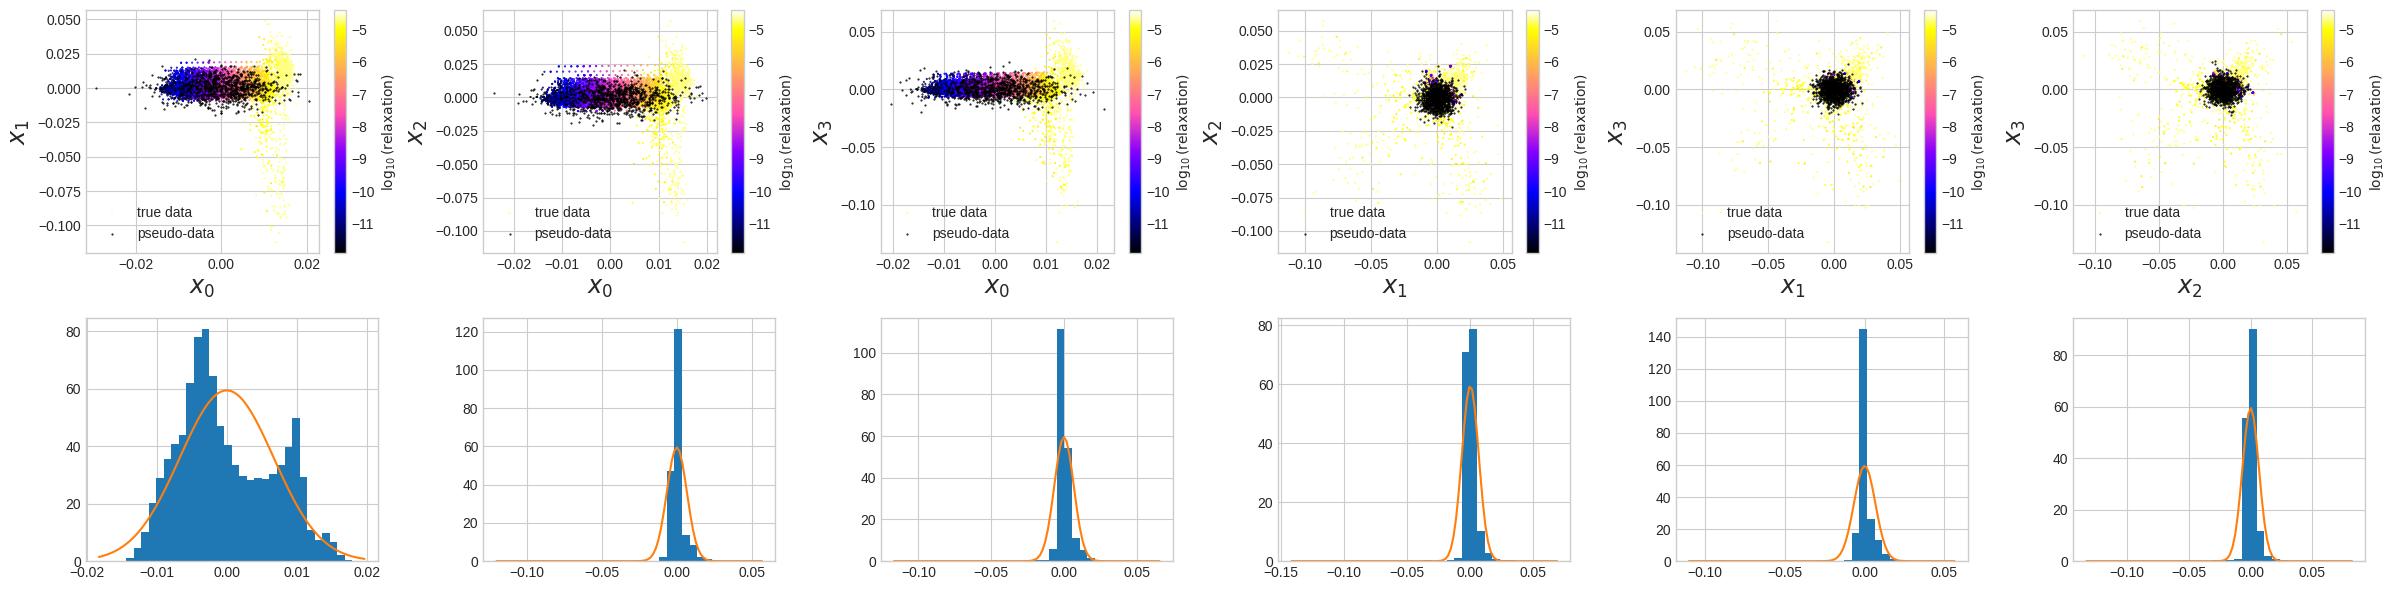

In [25]:
_markersize = .25
_d_show = 3
ncols = _d_show*(_d_show+1)//2
fig,ax = pyplot.subplots(nrows=2,ncols=ncols,figsize=(ncols*4,6))
_c = 0
for j1 in range(_d_show+1):
    for j2 in range(j1+1,_d_show+1):
        cax = ax[0,_c].scatter(inputs_zca_t[:,j1],inputs_zca_t[:,j2],c=torch.log10(relaxations_t[updated_t]),cmap="gnuplot2",s=_markersize,label="true data")
        fig.colorbar(cax,label=r"$\log_{10}(\mathrm{relaxation})$")
        _iiddata = (torch.randn(1000,2,device=DEVICE)*inputs_zca_std[[j1,j2]]+inputs_zca_mean[[j1,j2]]).to("cpu")
        ax[0,_c].scatter(_iiddata[:,0],_iiddata[:,1],s=_markersize,label="pseudo-data",color="k")
        ax[0,_c].set_xlabel(r"$x_%d$"%j1,fontsize="xx-large")
        ax[0,_c].set_ylabel(r"$x_%d$"%j2,fontsize="xx-large")
        ax[0,_c].legend(frameon=False)
        _c += 1
for j in range(ncols):
    ax[1,j].hist(inputs_zca_t[:,j],bins=32,density=True)
    _xlow,_xhigh = ax[1,j].get_xlim()
    _xticks = torch.linspace(_xlow,_xhigh,101) 
    _pdfticks = torch.exp(torch.distributions.Normal(inputs_zca_mean[j].to("cpu"),inputs_zca_std[j].to("cpu")).log_prob(_xticks))
    ax[1,j].plot(_xticks,_pdfticks)
fig.tight_layout()

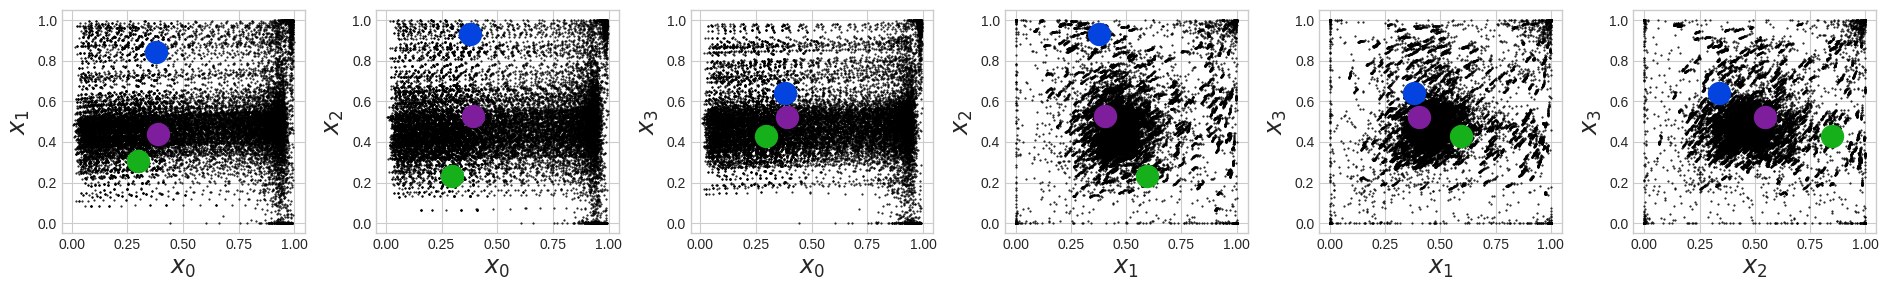

In [26]:
def map_to_unifs(x_raw):
    assert x_raw.size(-1)==(1+Nx**2+Ns*Nt*Nx)
    x = (x_raw-inputs_raw_t_mean)/inputs_raw_t_std
    x_zca_raw = torch.einsum("ij,...j->...i",W_white,x)
    x_zca = (x_zca_raw-inputs_zca_mean)/inputs_zca_std
    #u = vf_normed_zca_normed.clone()
    # vf_normed_zca_normed_finite = torch.isfinite(vf_normed_zca_normed)
    # u[vf_normed_zca_normed_finite] = torch.distributions.Normal(0,1).cdf(vf_normed_zca_normed[vf_normed_zca_normed_finite])
    u = torch.distributions.Normal(0,1).cdf(x_zca)
    u[u<=0] = EPS64 
    u[u>=1] = 1-EPS64
    return u
_u = map_to_unifs(inputs_raw_t.to(DEVICE)).to("cpu")
_u_for_next_plot = torch.rand((3,1+Nx**2+Ns*Nt*Nx),generator=torch.Generator().manual_seed(15))
_markersize = .25
_d_show = 3
ncols = _d_show*(_d_show+1)//2
fig,ax = pyplot.subplots(nrows=1,ncols=ncols,figsize=(ncols*3+1,3))
_c = 0
for j1 in range(_d_show+1):
    for j2 in range(j1+1,_d_show+1):
        ax[_c].scatter(_u[:,j1],_u[:,j2],s=_markersize,color="k")
        for i in range(_u_for_next_plot.size(0)):
            ax[_c].scatter(_u_for_next_plot[i,j1],_u[i,j2],s=250,color=COLORS[i])
        ax[_c].set_xlabel(r"$x_%d$"%j1,fontsize="xx-large")
        ax[_c].set_ylabel(r"$x_%d$"%j2,fontsize="xx-large")
        _c += 1
fig.tight_layout()

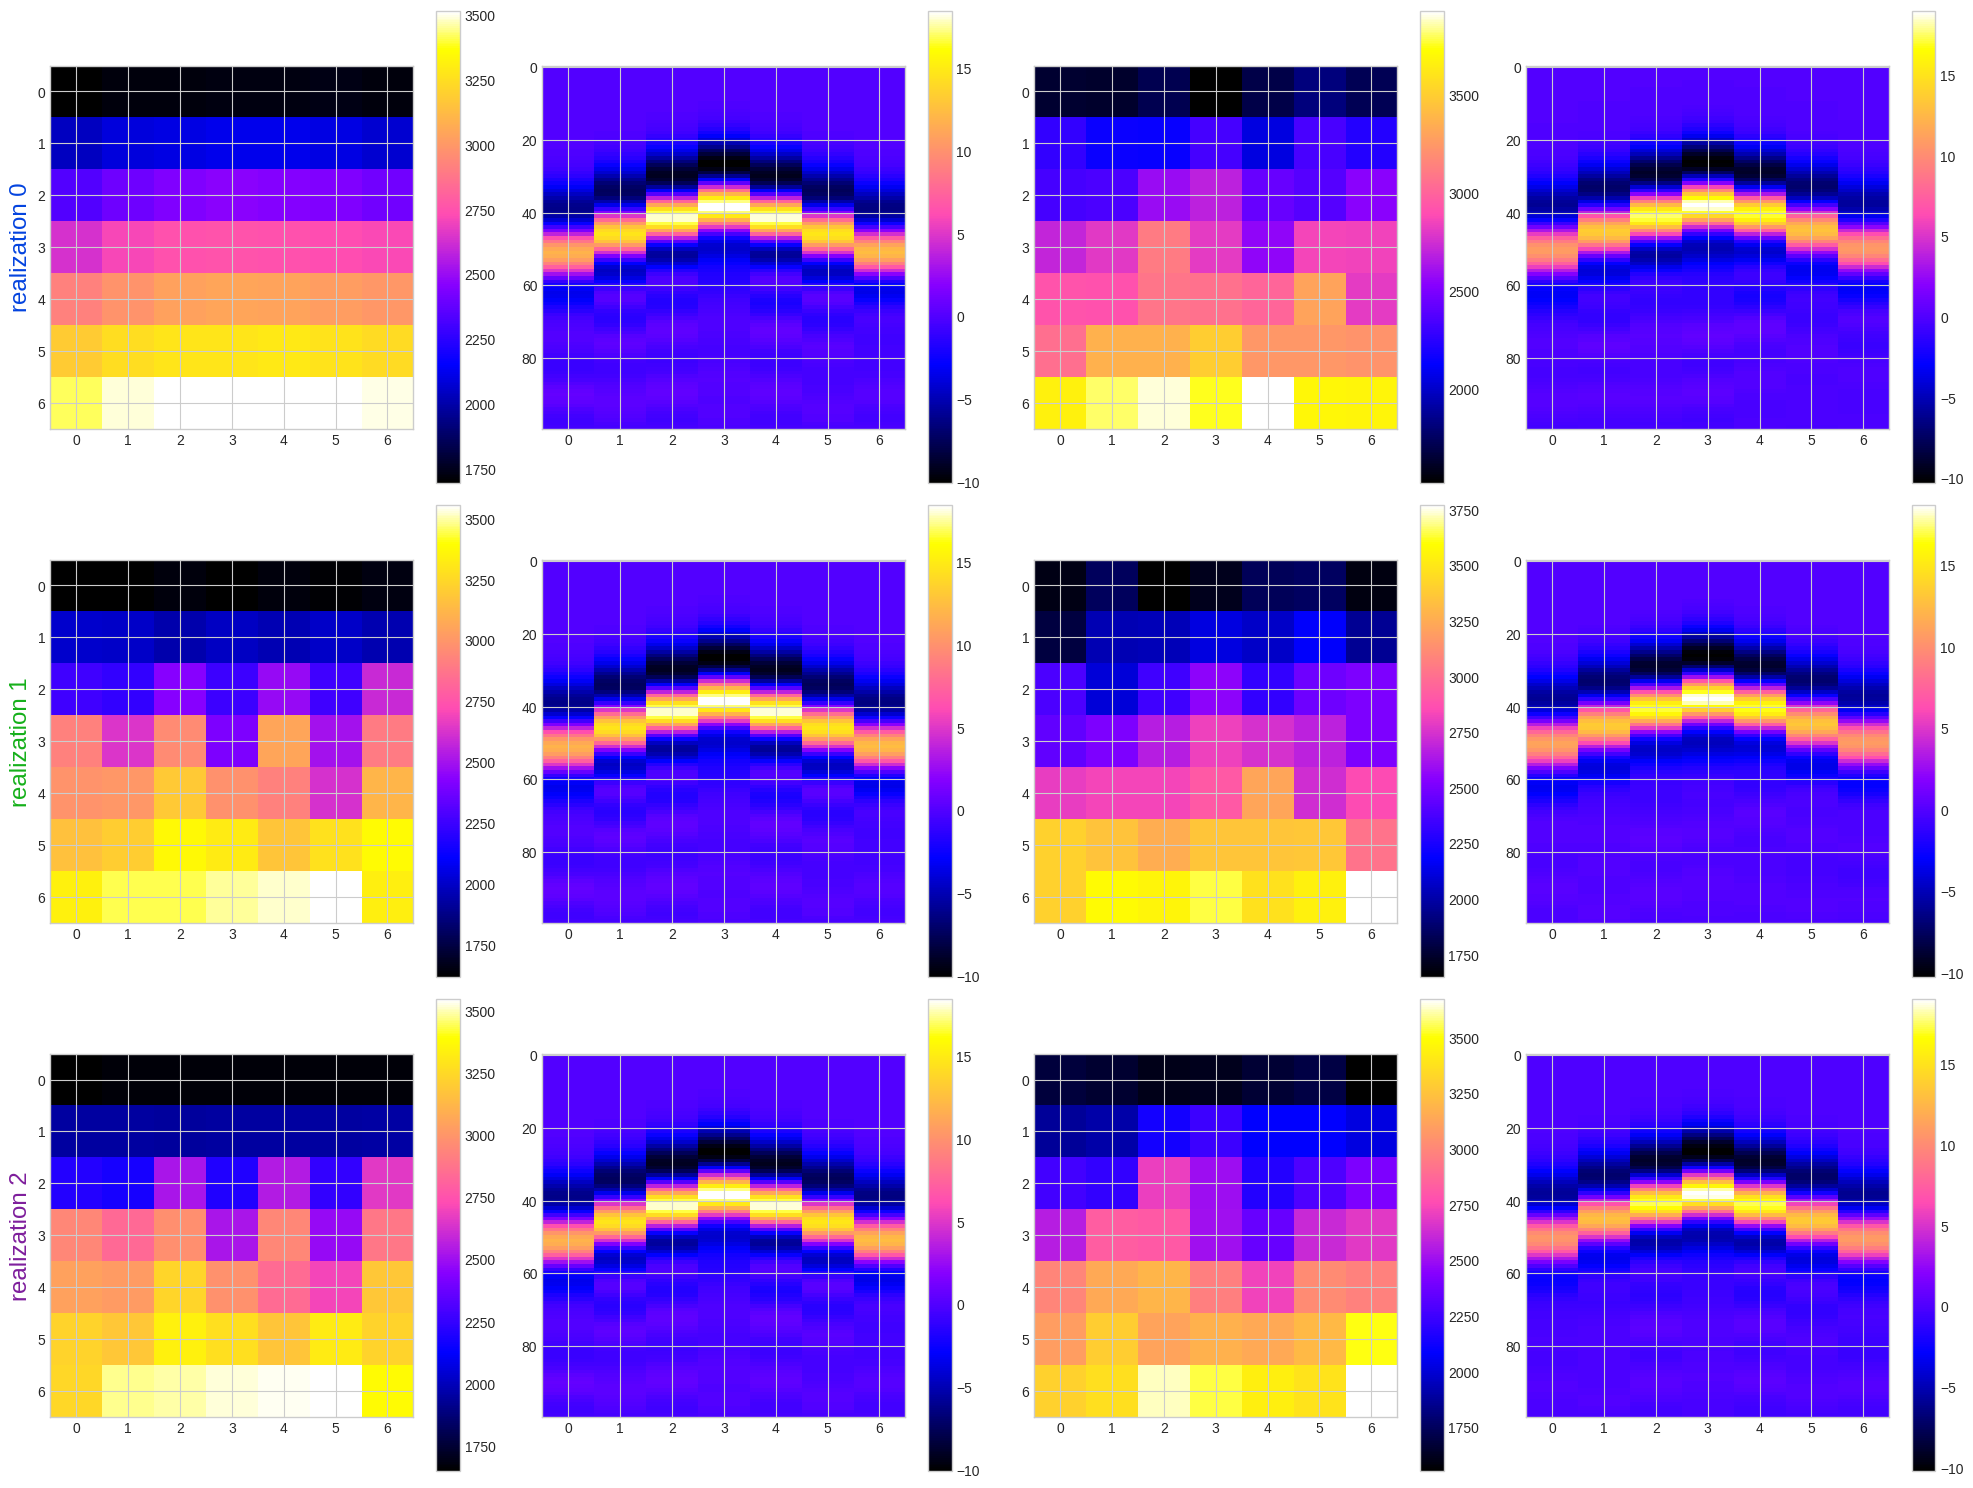

In [27]:
def map_from_unifs(u):
    assert u.size(-1)==(1+Nx**2+Ns*Nt*Nx)
    x_zca = torch.distributions.Normal(0,1).icdf(u)
    x_zca_raw = x_zca*inputs_zca_std+inputs_zca_mean
    x = torch.einsum("ij,...j->...i",Winv_white,x_zca_raw)
    x_raw = x*inputs_raw_t_std+inputs_raw_t_mean
    return x_raw
_pseudoinputs_raw = map_from_unifs(_u[:3].to(DEVICE)).to("cpu")
_pseudoinputs_raw = map_from_unifs(_u_for_next_plot.to(DEVICE)).to("cpu")
nrows = _pseudoinputs_raw.size(0)

fig,ax = pyplot.subplots(nrows=nrows,ncols=4,figsize=(5*4,5*nrows))
ax = ax.reshape((nrows,4))
for i in range(nrows):
    cax = ax[i,0].imshow(inputs_raw_t[i,1:(1+Nx*Nx)].reshape((Nx,Nx)),cmap="gnuplot2")
    fig.colorbar(cax)
    cax = ax[i,1].imshow(inputs_raw_t[i,(1+Nx*Nx):].reshape((Ns,Nt,Nx))[2],cmap="gnuplot2")
    ax[i,1].set_aspect(Nx/Nt)
    fig.colorbar(cax)
    cax = ax[i,2].imshow(_pseudoinputs_raw[i,1:(1+Nx*Nx)].reshape((Nx,Nx)),cmap="gnuplot2")
    fig.colorbar(cax)
    cax = ax[i,3].imshow(_pseudoinputs_raw[i,(1+Nx*Nx):].reshape((Ns,Nt,Nx))[2],cmap="gnuplot2")
    ax[i,3].set_aspect(Nx/Nt)
    fig.colorbar(cax)
    ax[i,0].set_ylabel("realization %d"%i,color=COLORS[i],fontsize="xx-large")
fig.tight_layout()

In [28]:
from gauss_newton_solver import J_F_func
def map_unifs_pseudoinputs_raw_pseudooutputs(u):
    R = u.size(0)
    pseudoinputs_raw = map_from_unifs(u)
    relaxations = torch.exp(pseudoinputs_raw[:,0])
    v = pseudoinputs_raw[:,1:(1+Nx*Nx)].reshape((R,Nx,Nx))
    w = pseudoinputs_raw[:,(1+Nx*Nx):].reshape((R,Ns,Nt,Nx))
    J,F = J_F_func(v,w,p)
    J = J.reshape((R,Ns*Nt*Nx,Nx*Nx))
    JtJ = torch.einsum("rji,rjk->rik",J,J)
    Theta = JtJ+relaxations[:,None,None]*torch.eye(Nx*Nx,device=DEVICE)
    L = torch.linalg.cholesky(Theta,upper=False) # may need to use cholesky_ex for some realizations
    pseudoutputs_raw = L[:,lti0,lti1]
    pseudoutputs = (pseudoutputs_raw-outputs_raw_t_mean)/outputs_raw_t_std
    return pseudoinputs_raw,pseudoutputs
_pseudoinputs_raw,_pseudooutputs = map_unifs_pseudoinputs_raw_pseudooutputs(_u_for_next_plot.to(DEVICE))
print("_pseudoinputs_raw.shape = %s"%str(tuple(_pseudoinputs_raw.shape)))
print("_pseudooutputs.shape = %s"%str(tuple(_pseudooutputs.shape)))

_pseudoinputs_raw.shape = (3, 3550)
_pseudooutputs.shape = (3, 1225)


In [75]:
fgp = fastgps.FastGPDigitalNetB2(
    seqs = (1+Nx*Nx+Ns*Nt*Nx),
    seed_for_seq = 7,
    device = DEVICE,
    shape_batch = (len(lti0),),
    lengthscales = 1e-5,
    requires_grad_noise = False,
    alpha = 1,
    )
u_fastgp = fgp.get_x_next(n=2**10)
pseudoinputs_raw_fgp,pseudooutputs_fgp = map_unifs_pseudoinputs_raw_pseudooutputs(u_fastgp)
print("inputs_raw_t.shape = %s"%str(tuple(inputs_raw_t.shape)))
print("pseudoinputs_raw_fgp.shape = %s"%str(tuple(pseudoinputs_raw_fgp.shape)))
print("pseudooutputs_fgp.shape = %s"%str(tuple(pseudooutputs_fgp.shape)))
fgp.add_y_next(pseudooutputs_fgp.T)

inputs_raw_t.shape = (22224, 3550)
pseudoinputs_raw_fgp.shape = (1024, 3550)
pseudooutputs_fgp.shape = (1024, 1225)


In [76]:
fit_data_fgp = fgp.fit(
    loss_metric = "GCV",
    #cv_weights = 1/torch.linalg.norm(pseudooutputs_fgp.to(DEVICE),dim=1),
    iterations = 100, 
    verbose = 10,
    stop_crit_wait_iterations = np.inf,
    store_hists = True,
)

     iter of 1.0e+02 | loss       | term1      | term2     
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 1.18e+06   | nan        | 3.74e+03  
            1.00e+01 | 6.33e+05   | nan        | 1.07e+01  
            2.00e+01 | 4.57e+05   | nan        | 1.17e+00  
            3.00e+01 | 4.50e+05   | nan        | 3.05e-01  
            4.00e+01 | 4.48e+05   | nan        | 1.62e-01  
            5.00e+01 | 4.48e+05   | nan        | 8.00e-02  
            6.00e+01 | 4.48e+05   | nan        | 8.24e-02  
            7.00e+01 | 4.48e+05   | nan        | 1.13e-01  
            8.00e+01 | 4.48e+05   | nan        | 1.17e-01  
            9.00e+01 | 4.48e+05   | nan        | 1.17e-01  
            1.00e+02 | 4.49e+05   | nan        | 1.07e-01  


dict_keys(['iterations', 'loss_hist', 'scale_hist', 'lengthscales_hist', 'noise_hist', 'task_kernel_hist'])


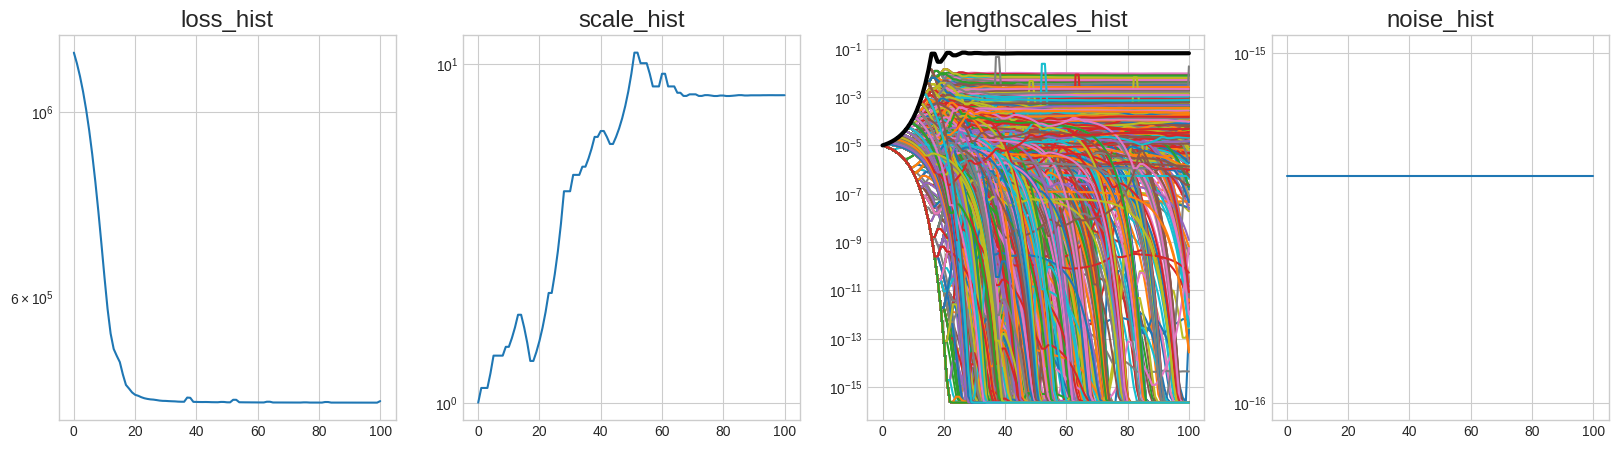

In [77]:
print(fit_data_fgp.keys())
keys_to_plot_log10ed = [
    ('loss_hist',True), # switch to false if using MLL
    ('scale_hist',True),
    ('lengthscales_hist',True),
    ('noise_hist',True)]
ncols = len(keys_to_plot_log10ed)
fig,ax = pyplot.subplots(nrows=1,ncols=ncols,figsize=(5*ncols,5))
for i,(key,log10ed) in enumerate(keys_to_plot_log10ed):
    ax[i].plot(torch.arange(fit_data_fgp[key].size(0)),fit_data_fgp[key])
    ax[i].set_title(key,fontsize="xx-large")
    if log10ed: ax[i].set_yscale('log',base=10)
ax[2].plot(torch.arange(fit_data_fgp["lengthscales_hist"].size(0)),fit_data_fgp["lengthscales_hist"][:,0],color="k",linewidth=3);

In [82]:
def fgp_predict(x):
    x_raw = x*inputs_raw_t_std+inputs_raw_t_mean
    u = map_to_unifs(x_raw)
    with torch.inference_mode() and torch.no_grad():
        y = fgp.post_mean(u).T
    return y
inputs_fgp = inputs_v[:100] # TODO: REMOVE [:100] 
outputs_v_hat_fgp = fgp_predict(inputs_fgp.to(DEVICE)) 
outputs_v_fgp = outputs_v[:inputs_fgp.size(0)]
l2rerrors_v = torch.linalg.norm(outputs_v_hat_fgp-outputs_v_fgp.to(DEVICE),dim=-1)/torch.linalg.norm(outputs_v_fgp.to(DEVICE),dim=-1)
print("l2 relative error: %.2e"%torch.mean(l2rerrors_v))

l2 relative error: 9.19e-01


## MLP

In [109]:
import gc
gc.collect()
torch.cuda.empty_cache()

save_dir = outdir_chonknoris
name = "MLP"
resume = False

dl_mlp_t = torch.utils.data.DataLoader(ds_t,batch_size=2**8,collate_fn=tuple,shuffle=True)
dl_mlp_v = torch.utils.data.DataLoader(ds_v,batch_size=len(ds_v),collate_fn=tuple,shuffle=False)
print("len(dl_mlp_t) = %d"%len(dl_mlp_t))
print("len(dl_mlp_v) = %d"%len(dl_mlp_v))
print()

nn = chonknoris.MLP(mlp_layer_nodes=[1+Nx**2+Ns*Nt*Nx]+3*[250]+[Nx**2*(1+Nx**2)//2],activation_function=torch.nn.Tanh())
#nn = chonknoris.MLP(mlp_layer_nodes=[1+Nx**2+Ns*Nt*Nx]+5*[1000]+[Nx**2*(1+Nx**2)//2],activation_function=torch.nn.Tanh())
lnn = chonknoris.LightningNN(nn,lr=1e-2,use_l2rerror_loss=True).to(DEVICE)
print(lnn)

csv_logger = lightning.pytorch.loggers.CSVLogger(save_dir=save_dir,name=name,version='csv')
trainer = lightning.Trainer(
    max_epochs = 25,
    logger = [csv_logger],
    #accelerator = "cpu",
    #limit_train_batches=2**10,
    #log_every_n_steps = 1e10,
    enable_progress_bar = True,
    #num_sanity_val_steps = 0,
    #gradient_clip_val = 1.0,
    #gradient_clip_algorithm = "norm",
  )
trainer.fit(
    model = lnn, 
    train_dataloaders = dl_mlp_t,
    val_dataloaders = dl_mlp_v,
    ckpt_path = sorted(glob.glob("./%s/%s/csv/checkpoints/*.ckpt"%(save_dir,name)),key=os.path.getmtime)[-1] if resume else None,
)


Trainer will use only 1 of 7 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=7)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory ./data/RES7.Style_B.SAVE/MODELS_L/MLP/csv exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory ./data/RES7.Style_B.SAVE/MODELS_L/MLP/csv/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6]

  | Name | Type | Params | Mode 
--------------------------------------
0 | nn   | MLP  | 1.3 M  | train
--------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.283     Total estimated model params size (MB)
7         Modules in train mode
0         M

len(dl_mlp_t) = 22
len(dl_mlp_v) = 1

LightningNN(
  (nn): MLP(
    (nn_sequential): Sequential(
      (0): Linear(in_features=3550, out_features=250, bias=True)
      (1): Tanh()
      (2): Linear(in_features=250, out_features=250, bias=True)
      (3): Tanh()
      (4): Linear(in_features=250, out_features=250, bias=True)
      (5): Tanh()
      (6): Linear(in_features=250, out_features=1225, bias=True)
    )
  )
)
                                                                            

/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=255` in the `DataLoader` to improve performance.
/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=255` in the `DataLoader` to improve performance.
/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (22) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 24: 100%|██████████| 22/22 [00:00<00:00, 30.81it/s, v_num=csv, val_loss=0.753, val_rmse=0.868, val_avg_l2error=29.80, val_avg_l2rerror=0.867, train_loss=0.363, train_rmse=0.603, train_avg_l2error=19.80, train_avg_l2rerror=0.571]

`Trainer.fit` stopped: `max_epochs=25` reached.


Epoch 24: 100%|██████████| 22/22 [00:01<00:00, 16.61it/s, v_num=csv, val_loss=0.753, val_rmse=0.868, val_avg_l2error=29.80, val_avg_l2rerror=0.867, train_loss=0.363, train_rmse=0.603, train_avg_l2error=19.80, train_avg_l2rerror=0.571]


,train_avg_l2error,val_avg_l2error,train_avg_l2rerror,val_avg_l2rerror,train_loss,val_loss,train_rmse,val_rmse
0,37.029849,34.082980,1.081516,0.991627,1.190055,0.978297,1.072875,0.989089
3,30.925090,31.560821,0.898007,0.915104,0.813019,0.846254,0.901527,0.919921
6,28.016100,29.988459,0.812432,0.870796,0.672673,0.762971,0.820037,0.873482
9,25.603307,29.167621,0.741003,0.846337,0.568601,0.723791,0.753944,0.850759
12,23.875277,29.209829,0.690277,0.848532,0.500400,0.725117,0.707130,0.851538
15,22.404869,29.124516,0.646909,0.847086,0.446764,0.719817,0.668251,0.848421
18,21.245257,29.558592,0.612901,0.859229,0.407970,0.742013,0.638582,0.861402
21,20.373849,29.508940,0.587226,0.858045,0.380018,0.738492,0.616220,0.859356
24,19.820436,29.803157,0.571219,0.867166,0.363282,0.752888,0.602607,0.867691


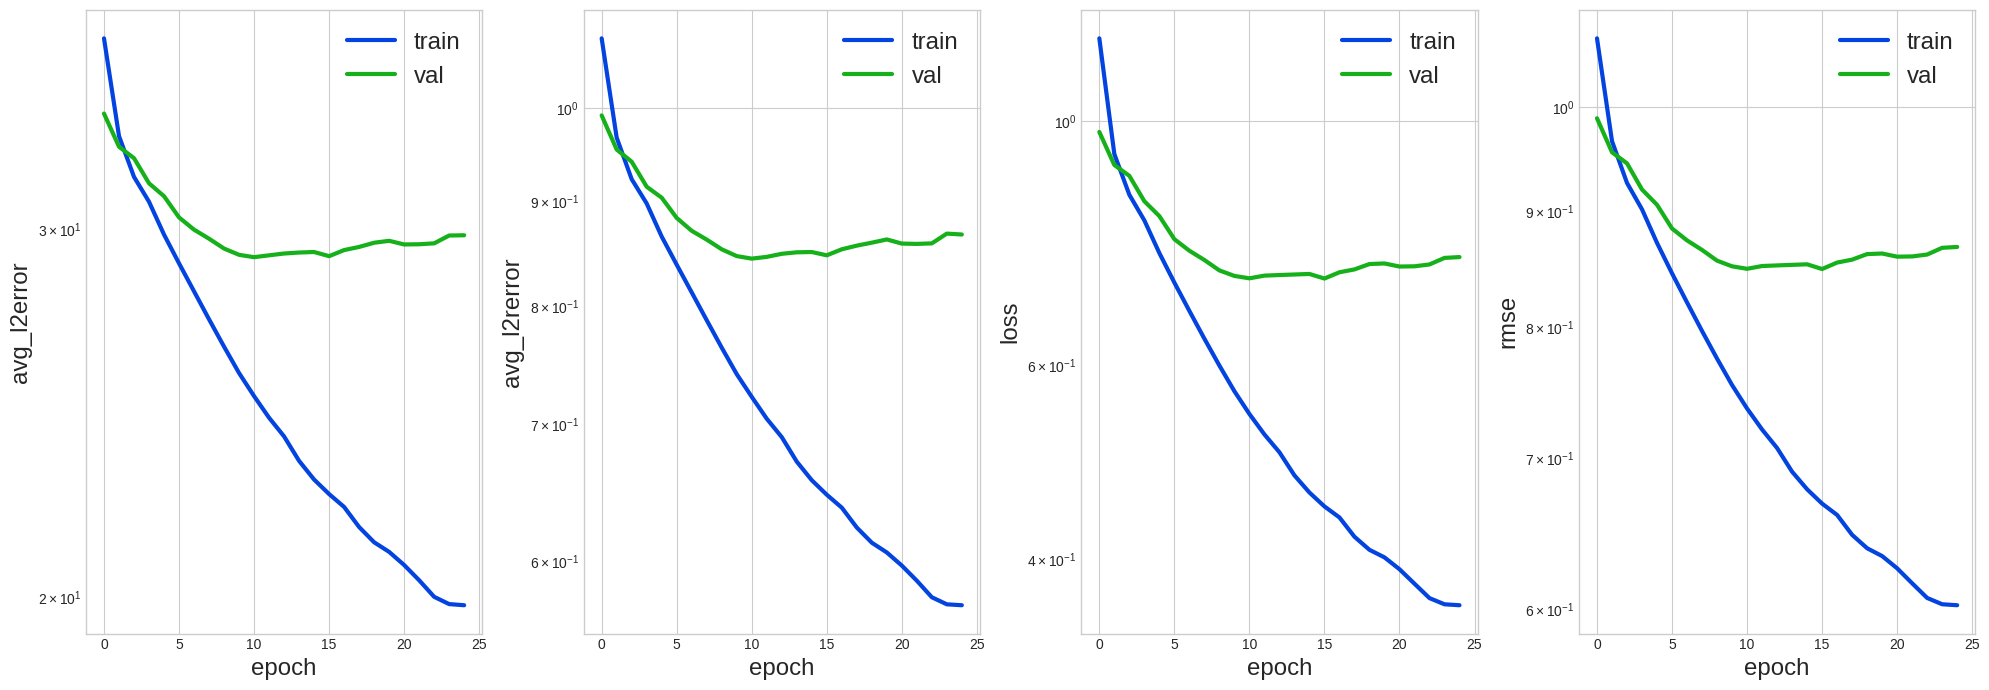

In [110]:
metrics = chonknoris.parse_metrics("%s/%s/csv/metrics.csv"%(save_dir,name))
fig,ax = chonknoris.plot_metrics(metrics,linewidth=LWTHICK,color_train=COLORS[0],color_val=COLORS[1],s0=0)
fig.tight_layout()
metrics.iloc[::max(1,len(metrics)//8)]

In [111]:
lnn = lnn.to(DEVICE) 
with torch.no_grad(), torch.inference_mode():
    outputs_v_hat_sgp_raw_mlp = lnn(inputs_v.to(DEVICE))
print("l2 relative error: %.2e"%(torch.linalg.norm(outputs_v_hat_sgp_raw_mlp-outputs_v.to(DEVICE),dim=-1)/torch.linalg.norm(outputs_v.to(DEVICE),dim=-1)).mean())

l2 relative error: 8.67e-01


## GPR

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()
sgp = fastgps.StandardGP(
    1+Nx*Nx+Ns*Nt*Nx,
    data={"x":inputs_t.to(DEVICE),"y":outputs_t.T.to(DEVICE)},
    shape_batch=[Nx*Nx*(1+Nx*Nx)//2],
    device=DEVICE,
    #shape_scale = [Nx*Nx*(1+Nx*Nx)//2,1],
    lengthscales=1+Nx*Nx+Ns*Nt*Nx,
    #shape_lengthscales=[1],
    shape_lengthscales=[1+Nx*Nx+Ns*Nt*Nx],
    noise = 1e-8,
    requires_grad_noise=True,
    compile_dist_func=True,
    kernel_class="matern52",
    tfs_scale = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    tfs_lengthscales = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    tfs_noise = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_scale = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_lengthscales = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_noise = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_scale = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
    # tfs_lengthscales = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
    # tfs_noise = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
)
for pname,pval in sgp.named_parameters():
    print("%s.shape = %s"%(pname,str(tuple(pval.shape))))
print()
fit_data_sgp = sgp.fit(
    loss_metric = "CV",
    #cv_weights = 1/torch.linalg.norm(outputs_t.to(DEVICE),dim=1),
    # cv_weights = torch.log10(1/relaxations_t[updated_t]).to(DEVICE)**4,
    # cv_weights = torch.log10(relaxations_t[updated_t].to(DEVICE))/torch.linalg.norm(outputs_t.to(DEVICE),dim=1),
    iterations = 50,
    verbose = 1,
    store_hists = True,
    stop_crit_wait_iterations = 100,
    stop_crit_improvement_threshold = 1e-1,
    #lr = 1e0,
    #optimizer=torch.optim.Rprop(sgp.parameters(),lr=1e0),#,etas=(0.5,1.2),step_sizes=(0,10)),
    #optimizer=torch.optim.Adam(sgp.parameters(),lr=1e0,amsgrad=True),#,lr=5e-2),
    )

raw_scale.shape = (1,)
raw_lengthscales.shape = (1801,)
raw_noise.shape = (1,)
raw_factor_task_kernel.shape = (1, 0)
raw_noise_task_kernel.shape = (1,)

     iter of 5.0e+01 | loss       | term1      | term2     
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 1.10e+08   | nan        | nan       


KeyboardInterrupt: 

In [99]:
outputs_v_hat_sgp = sgp.post_mean(inputs_v.to(DEVICE)).T
l2rerrors_v = torch.linalg.norm(outputs_v_hat_sgp-outputs_v.to(DEVICE),dim=-1)/torch.linalg.norm(outputs_v.to(DEVICE),dim=-1)
print("l2 relative error: %.2e"%torch.mean(l2rerrors_v))

l2 relative error: 3.91e-01


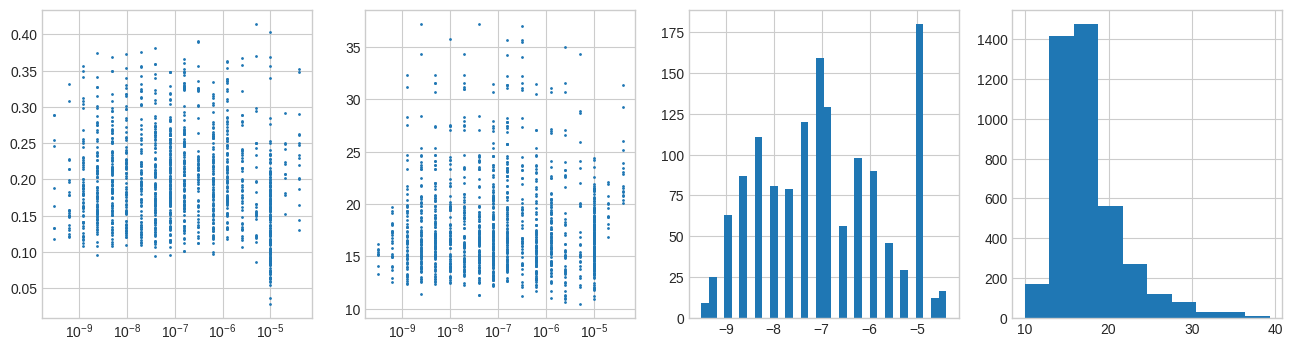

In [33]:
fig,ax = pyplot.subplots(nrows=1,ncols=4,figsize=(16,4))
ax[0].scatter(relaxations_v[updated_v].cpu(),l2rerrors_v.cpu(),s=1)
ax[0].set_xscale("log",base=10)
ax[1].scatter(relaxations_v[updated_v].cpu(),torch.linalg.norm(outputs_v.to(DEVICE),dim=1).cpu(),s=1)
ax[1].set_xscale("log",base=10)
ax[2].hist(torch.log10(relaxations_v[updated_v].cpu()),bins=32);
ax[3].hist(torch.linalg.norm(outputs_t.to(DEVICE),dim=1).cpu());

dict_keys(['iterations', 'loss_hist', 'scale_hist', 'lengthscales_hist', 'noise_hist', 'task_kernel_hist'])


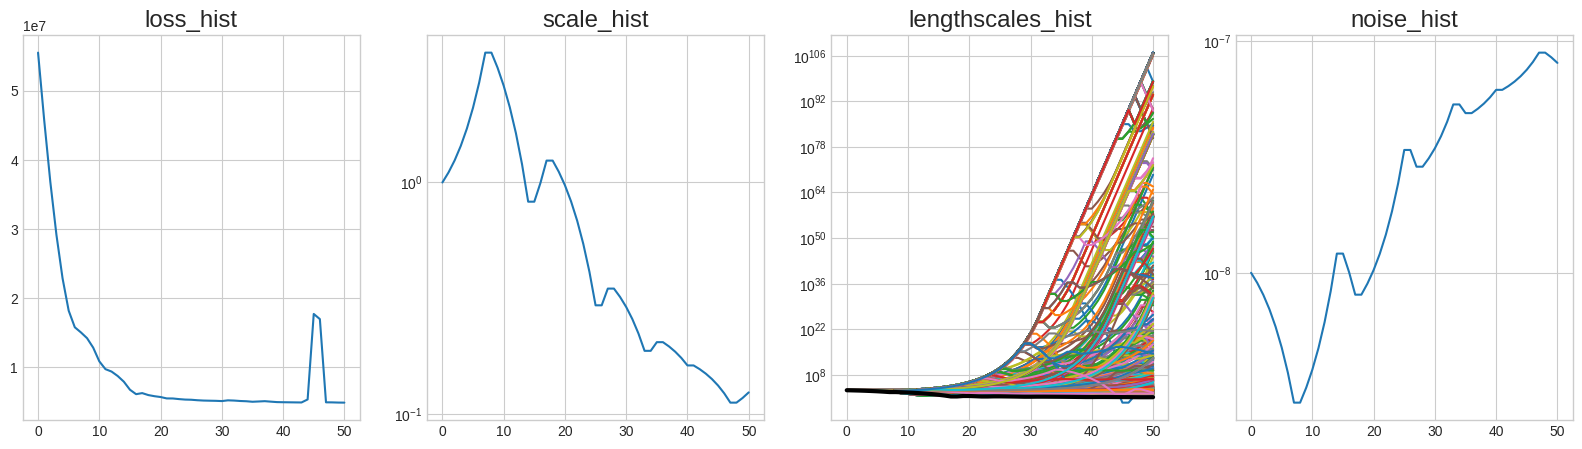

In [34]:
print(fit_data_sgp.keys())
keys_to_plot_log10ed = [
    ('loss_hist',False),
    ('scale_hist',True),
    ('lengthscales_hist',True),
    ('noise_hist',True)]
ncols = len(keys_to_plot_log10ed)
fig,ax = pyplot.subplots(nrows=1,ncols=ncols,figsize=(5*ncols,5))
for i,(key,log10ed) in enumerate(keys_to_plot_log10ed):
    ax[i].plot(torch.arange(fit_data_sgp[key].size(0)),fit_data_sgp[key])
    ax[i].set_title(key,fontsize="xx-large")
    if log10ed: ax[i].set_yscale('log',base=10)
ax[2].plot(torch.arange(fit_data_sgp["lengthscales_hist"].size(0)),fit_data_sgp["lengthscales_hist"][:,0],color="k",linewidth=3);

## Inference

In [ ]:
#lmodel = lnn.to(DEVICE)
# lmodel = lambda x: sgp.post_mean(x).T
lmodel = fgp_predict
def predict(relaxations, v, w, JtF):
    assert relaxations.ndim==1 and v.ndim==2 and relaxations.size(0)==v.size(0)==w.size(0)
    inputs_raw = torch.cat([torch.log(relaxations[:,None]),v,w.flatten(start_dim=1)],dim=-1)
    inputs = (inputs_raw-inputs_raw_t_mean)/inputs_raw_t_std
    L = torch.zeros((v.size(0),Nx**2,Nx**2),device=v.device)
    with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var():
        L_raw_flat = lmodel(inputs)
    L_flat = L_raw_flat*outputs_raw_t_std+outputs_raw_t_mean
    L[:,lti0,lti1] = L_flat
    #L[:,_Nxr2,_Nxr2] = torch.exp(L[:,_Nxr2,_Nxr2])
    success = torch.ones(v.size(0),dtype=bool,device=v.device)
    # delta_try = torch.einsum("rji,rj->ri",L,torch.einsum("rij,rj->ri",L,JtF))
    delta_try = torch.cholesky_solve(JtF[success,:,None],L[success],upper=False)[...,0]
    return delta_try,success
# def predict(relaxations, v, w, JtF):
#     assert relaxations.ndim==1 and v.ndim==2 and relaxations.size(0)==v.size(0)==w.size(0)
#     inputs_raw = torch.cat([torch.log(relaxations)[:,None],v,w.flatten(start_dim=1)],dim=-1)
#     #inputs_raw = torch.cat([v,w.flatten(start_dim=1)],dim=-1)
#     inputs = (inputs_raw-inputs_raw_t_mean)/inputs_raw_t_std
#     L =  torch.empty((v.size(0),Nx**2,Nx**2),device=v.device)
#     with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var():
#         L_flat = lmodel(inputs)
#     L[:,lti0,lti1] = L_flat
#     # Theta = torch.einsum("rik,rlk->ril",L,L)-common_relaxation*_eyeNx2+relaxations[:,None,None]*_eyeNx2
#     # L,fails = torch.linalg.cholesky_ex(Theta,upper=False)
#     # success = fails==0
#     success = torch.ones(v.size(0),dtype=bool,device=v.device)
#     delta_try = torch.cholesky_solve(JtF[success,:,None],L[success],upper=False)[...,0]
#     return delta_try,success
R_infer = 15
num_newton_iter_infer = 30
vref = data["velocity"][data["vidxs"]][:R_infer].to(DEVICE)
w = data["wavefield"][data["vidxs"]][:R_infer].to(DEVICE)
#v0 = data["vs"][data["vidxs"]][:R_infer,0].to(DEVICE)
v0 = data["vs"][data["vidxs"]][:R_infer,10].to(DEVICE)
#v0 = outputs_v_hat_sgp_ig[:R_infer].reshape((R_infer,Nx,Nx))
_,data_infer = fwi_gn_solver(p,w,v0,num_newton_iter=num_newton_iter_infer,vref=vref,use_pca=False,predict=predict,print_rmse_flow=False,
                             #relaxation=1e-5,
                             relaxation=5e-9,
                             lr=1,
                             wiggle_factors_relaxation=(1/2,2),
                             wiggle_factors_lr=(1/2,2),
                             range_relaxations=(0,1e-3),
                             range_lrs = (0,100))
#_,data_infer = fwi_gn_solver(p,w,v0,num_newton_iter=num_newton_iter_infer,relaxation=4.8e-8,lr=1,vref=vref,use_pca=False,predict=predict,print_rmse_flow=False,wiggle_factor_relaxation=2,wiggle_factor_lr=2)


    iter of 30     | time      | RMSE                                                             | L2 relative error                                   | relaxations                                         | lrs                                                 |
                   |           | 5%           median       mean         95%          finite %     | 5%           median       mean         95%          | 5%           median       mean         95%          | 5%           median       mean         95%          |
    -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0              | 8.89e+00  | 3.47e-03     1.02e-02     9.99e-03     1.72e-02     100.0        | 2.64e-03     5.84e-03     5.77e-03     8.25e-03     | 1.00e-09     1.00e-09     1.00e-09     1.00e-09     | 1.00e+

KeyboardInterrupt: 

/home/aleksei.sorokin/DeepNewtonOperator/chonknoris/plots.py:99: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i,j].legend(frameon=False,fontsize="xx-large")


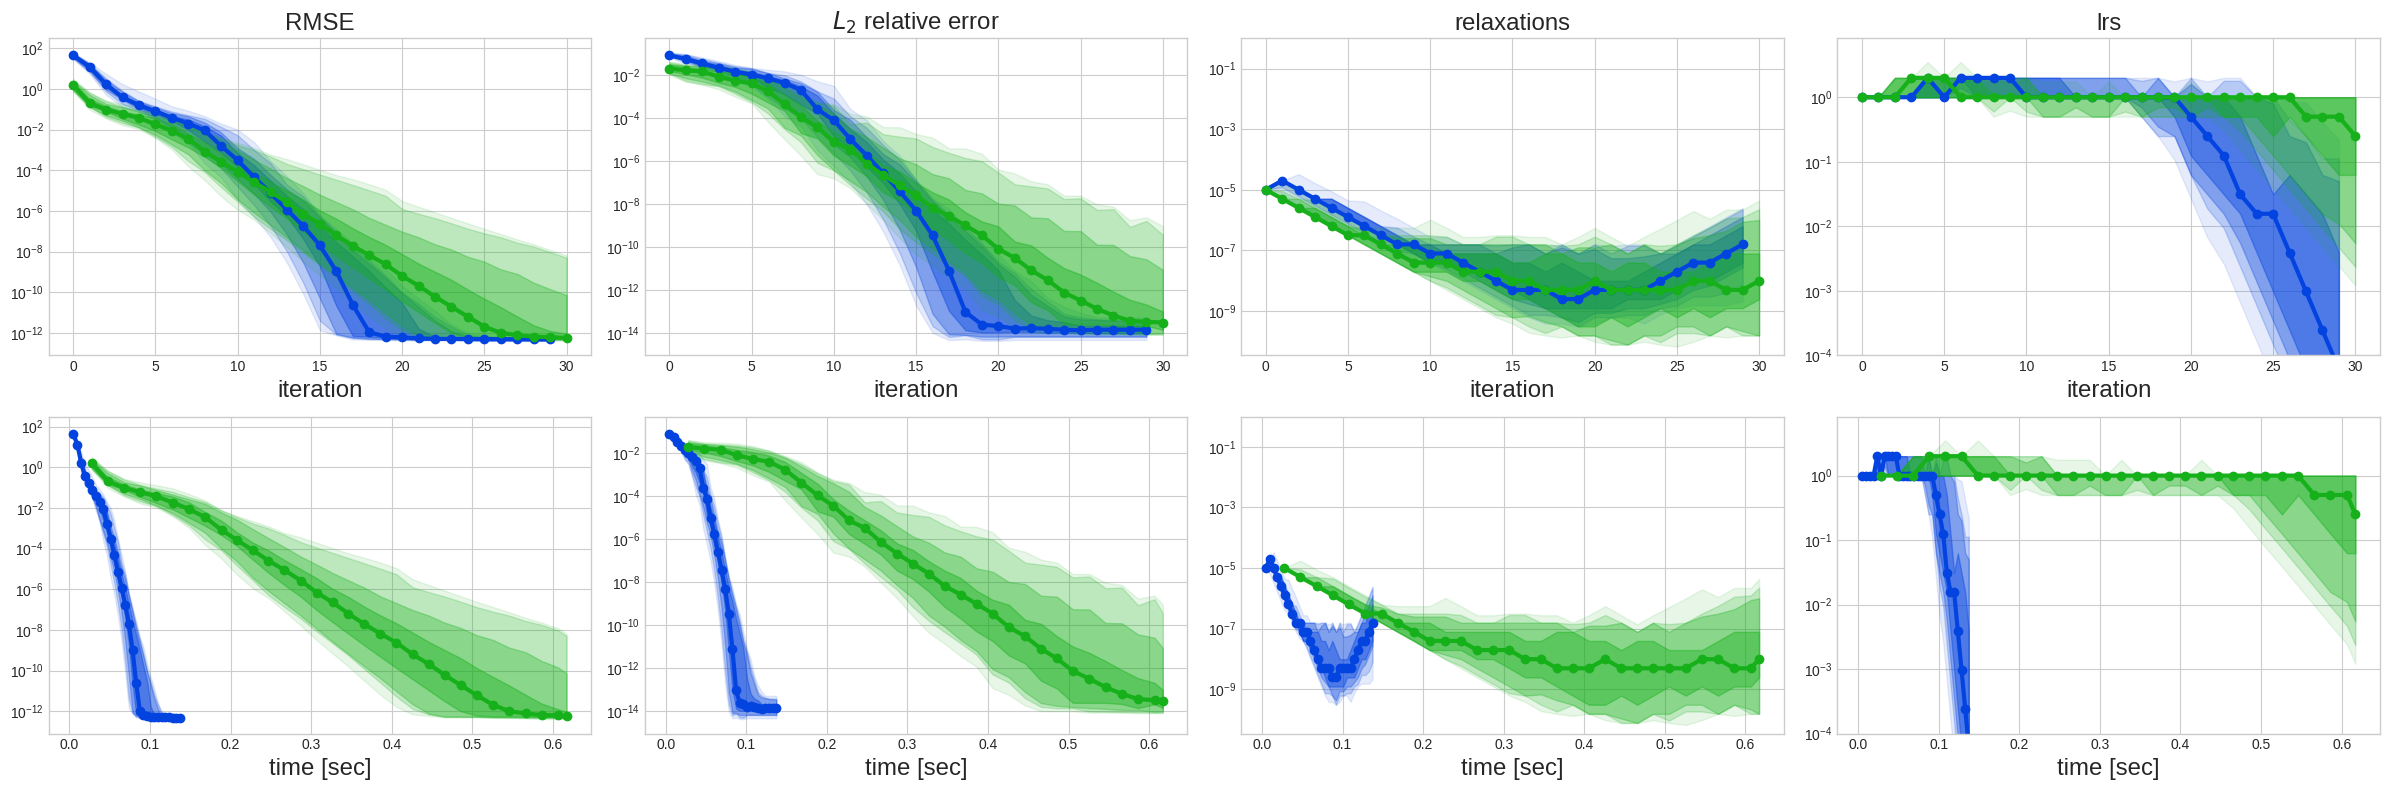

In [38]:
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [
                (None,data["rmses"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                (None,data_infer["rmses"],None)
            ],
            [
                (None,data["l2rerrors"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                (None,data_infer["l2rerrors"],None)],
            [
                (None,data["relaxations"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                (None,data_infer["relaxations"],None)],
            [
                (None,data["lrs"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                (None,data_infer["lrs"],None)],

        ],
        [
            [
                (data["times"][:num_newton_iter_infer].cumsum(0),data["rmses"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["rmses"],None)],
            [
                (data["times"][:num_newton_iter_infer].cumsum(0),data["l2rerrors"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["l2rerrors"],None)],
            [
                (data["times"][:num_newton_iter_infer].cumsum(0),data["relaxations"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["relaxations"],None)],
            [
                (data["times"][:num_newton_iter_infer].cumsum(0),data["lrs"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["lrs"],None)],

        ],
    ],
    sharex = False,
    titles = [["RMSE",r"$L_2$ relative error","relaxations","lrs"],[None,None,None,None]],
    xlabels = [["iteration"],["time [sec]"]],
    xlogscale = False,
    colors = COLORS,
    ylogscale = True,
    fsx=4,fsy=6)
for i in range(2):
    ax[i,2].set_ylim([ax[i,2].get_ylim()[0],1])
    ax[i,3].set_ylim([1e-4,ax[i,3].get_ylim()[1]])
fig.tight_layout()

tensor([0.0210, 0.0304, 0.0184, 0.0146, 0.0417])
tensor([7.9262e-15, 1.3685e-13, 1.3983e-14, 2.2431e-14, 9.8752e-15])


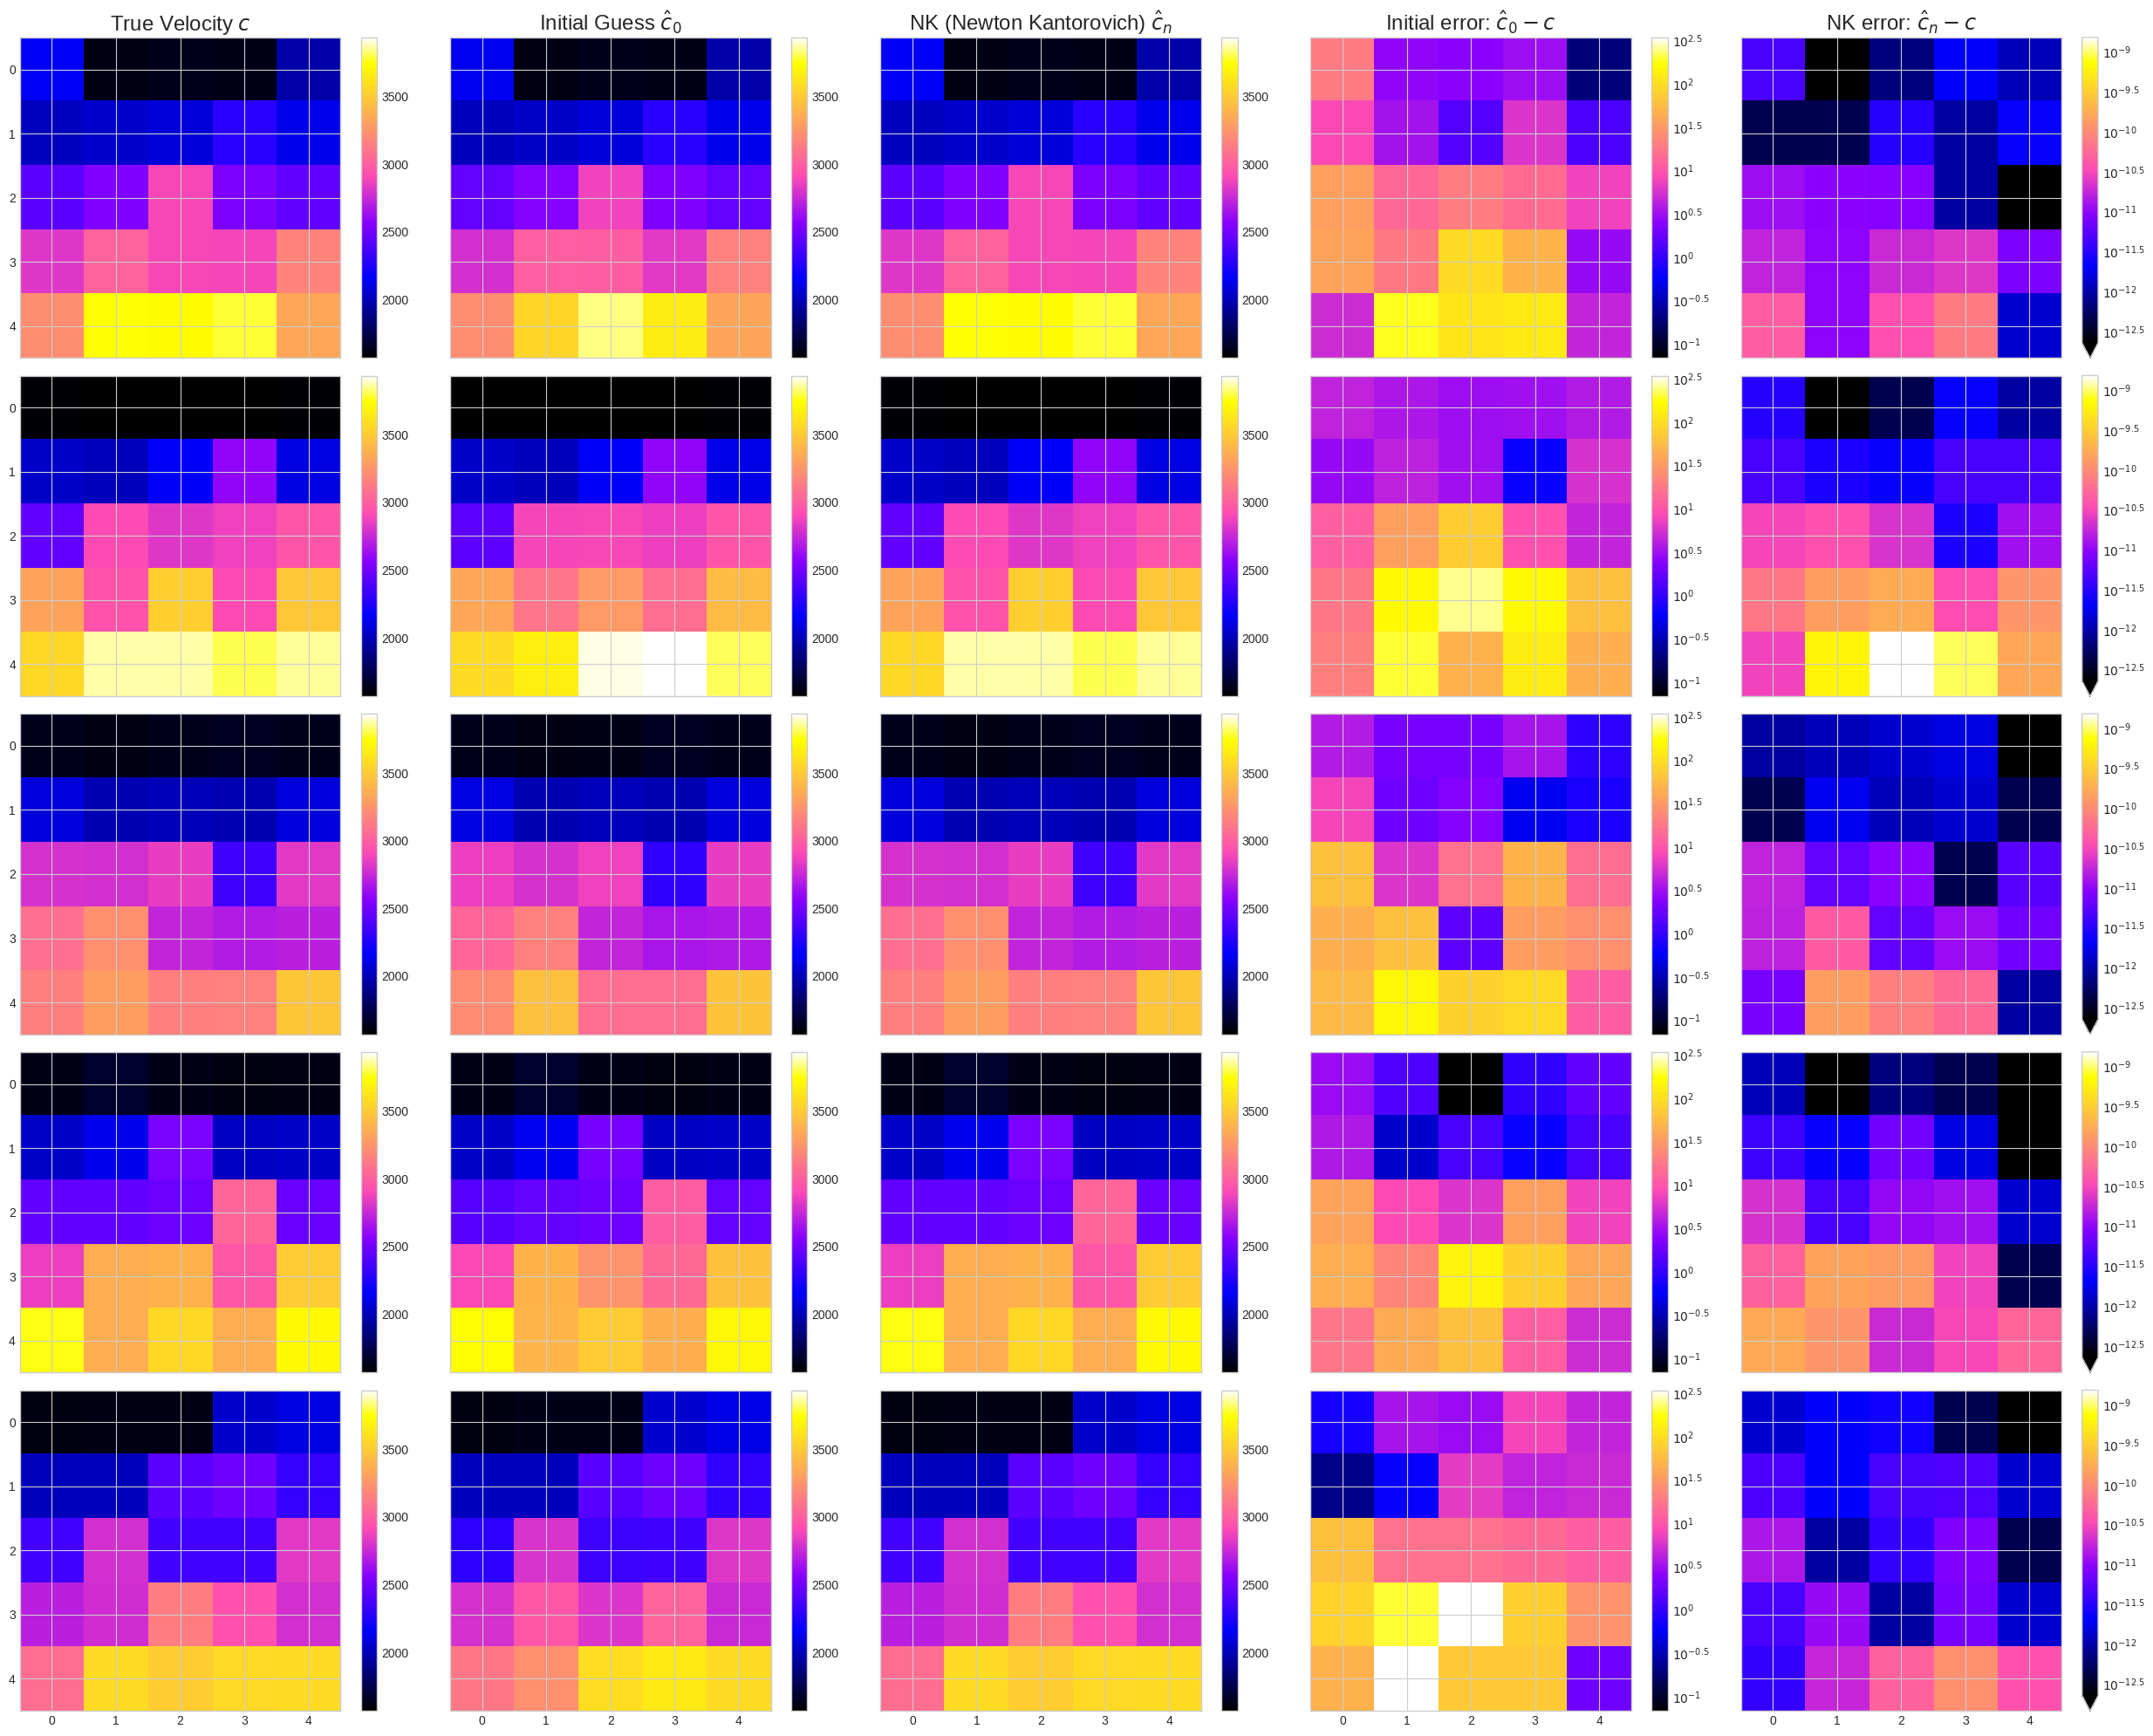

In [39]:
Rplt = 5
print(data_infer["l2rerrors"][:Rplt,0])
print(data_infer["l2rerrors"][:Rplt,-1])
plot_nk_velocities(vref.cpu()[:Rplt],data_infer["vs"][:Rplt,0].cpu(),data_infer["vs"][:Rplt,-1].cpu());